In [1]:
import pandas as pd
import numpy as np
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
import seaborn as sns
from src.dataloading import load_data
from src.eda import check_missing_values,handle_missing_values
sns.set_style("whitegrid")

In [6]:
df = pd.read_csv("../data/raw/MachineLearningRating_v3.txt", sep="|",
    na_values=[' ', '', 'NA'])
df

C:\Users\bemnet\AppData\Local\Temp\ipykernel_19960\2344027165.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/MachineLearningRating_v3.txt", sep="|",


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000093,31520,389,2015-04-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000094,31520,389,2015-06-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000095,31520,389,2015-08-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000096,31519,389,2014-07-01 00:00:00,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Passenger Liability,Passenger Liability,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,2.315000,0.0


In [7]:
print(df.shape)
# print(df.dtypes)

(1000098, 52)


In [81]:
categorical_cols = [
    'IsVATRegistered',
    'Citizenship',
    'LegalType',
    'Title',
    'Language',
    'Bank',
    'AccountType',
    'MaritalStatus',
    'Gender',
    'Country',
    'Province',
    'PostalCode',
    'MainCrestaZone',
    'SubCrestaZone',
    'ItemType',
    'mmcode',
    'VehicleType',
    'make',
    'Model',
    'bodytype',
    'AlarmImmobiliser',
    'TrackingDevice',
    'NewVehicle',
    'WrittenOff',
    'Rebuilt',
    'Converted',
    'CrossBorder',
    'TermFrequency',
    'ExcessSelected',
    'CoverCategory',
    'CoverType',
    'CoverGroup',
    'Section',
    'Product',
    'StatutoryClass',
    'StatutoryRiskType'
]

In [82]:
numerical_cols = [
    'UnderwrittenCoverID',
    'PolicyID',
    'RegistrationYear',
    'Cylinders',
    'cubiccapacity',
    'kilowatts',
    'NumberOfDoors',
    'CustomValueEstimate',
    'CapitalOutstanding',
    'NumberOfVehiclesInFleet',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'TotalPremium',
    'TotalClaims'
]

In [10]:
date_cols = [
    'TransactionMonth',
    'VehicleIntroDate'
]

## Handle Missing Values

In [83]:
 # Missing values summary
missing_summary = check_missing_values(df)

print("\nMissing Value Summary:")
display(missing_summary)

# Handle missing values
df = handle_missing_values(
    df,
    numerical_cols,
    categorical_cols
)


Missing Value Summary:


,Missing Values,Percentage (%)
NumberOfVehiclesInFleet,1000098,100.000000
VehicleIntroDate,552,0.055195


## Data Validation & Quality Checks

In [84]:
# Check duplicates
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

# Check negative financial values
negative_claims = (
    df['TotalClaims'] < 0
).sum()

negative_premium = (
    df['TotalPremium'] < 0
).sum()

print("Negative Claims:", negative_claims)

print("Negative Premiums:", negative_premium)

Duplicate Rows: 74
Negative Claims: 5
Negative Premiums: 288


Negative premium and claim values were identified in the dataset. These may represent refunds, reversals, policy cancellations, or accounting adjustments. Duplicate checks and validation procedures were performed to improve data reliability before analysis.

In [26]:
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [85]:
df['TransactionMonth'] = pd.to_datetime(
    df['TransactionMonth'],
   
    errors='coerce'
)
df['VehicleIntroDate'] = pd.to_datetime(
    df['VehicleIntroDate'],
    errors='coerce'
)

In [86]:
totalclaims_table = pd.DataFrame(
    df['TotalClaims'].describe()
)

# Rename column for cleaner display
totalclaims_table.columns = ['TotalClaims']

# Display table
display(totalclaims_table)

,TotalClaims
count,1.000098e+06
mean,6.486119e+01
std,2.384075e+03
min,-1.200241e+04
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,3.930921e+05


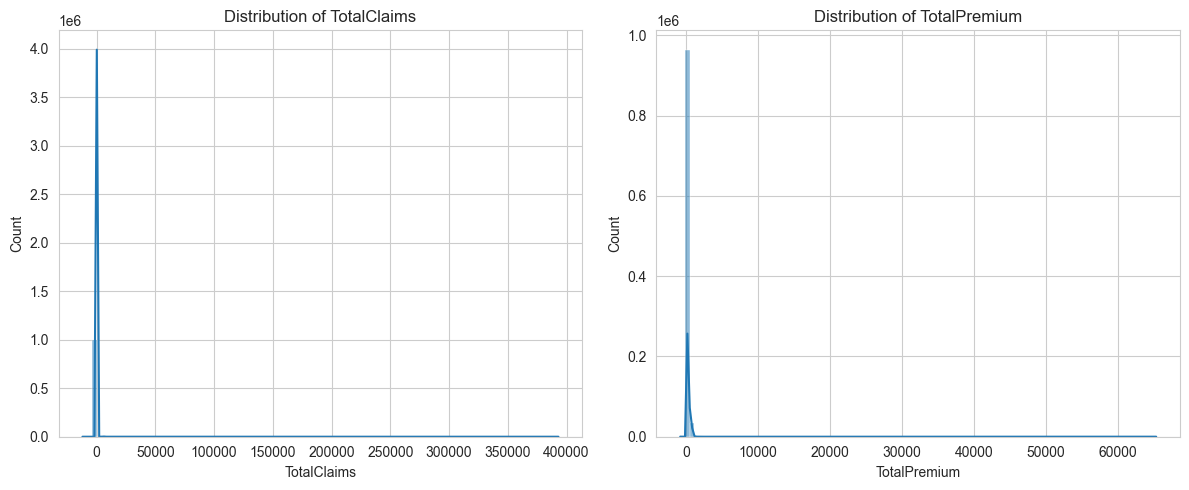

In [49]:
# Create figure
plt.figure(figsize=(12, 5))

# TotalClaims distribution
plt.subplot(1, 2, 1)
sns.histplot(df['TotalClaims'], bins=100, kde=True)
plt.title('Distribution of TotalClaims')
plt.xlabel('TotalClaims')

# TotalPremium distribution
plt.subplot(1, 2, 2)
sns.histplot(df['TotalPremium'], bins=100, kde=True)
plt.title('Distribution of TotalPremium')
plt.xlabel('TotalPremium')

plt.tight_layout()
plt.show()

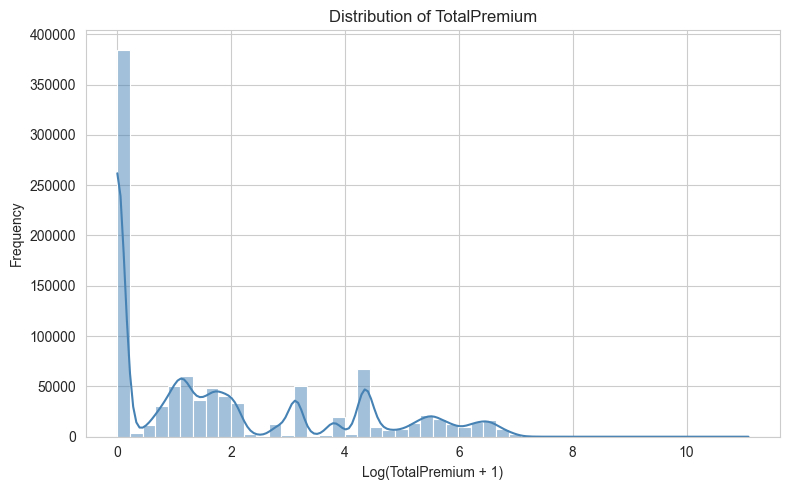

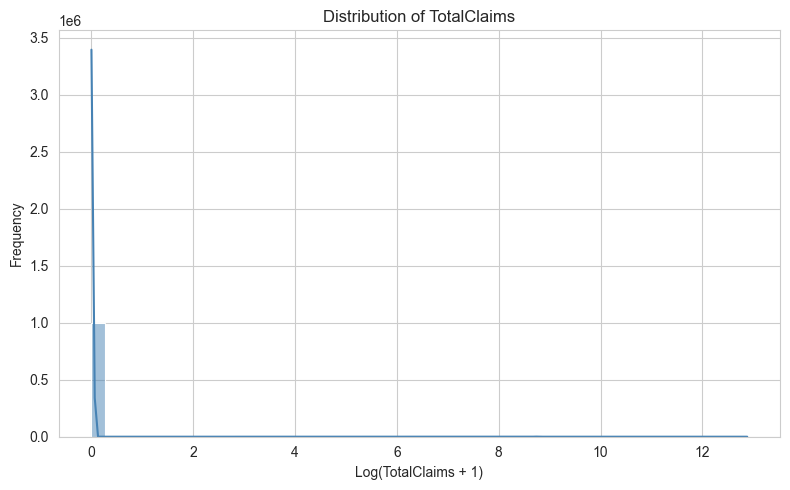

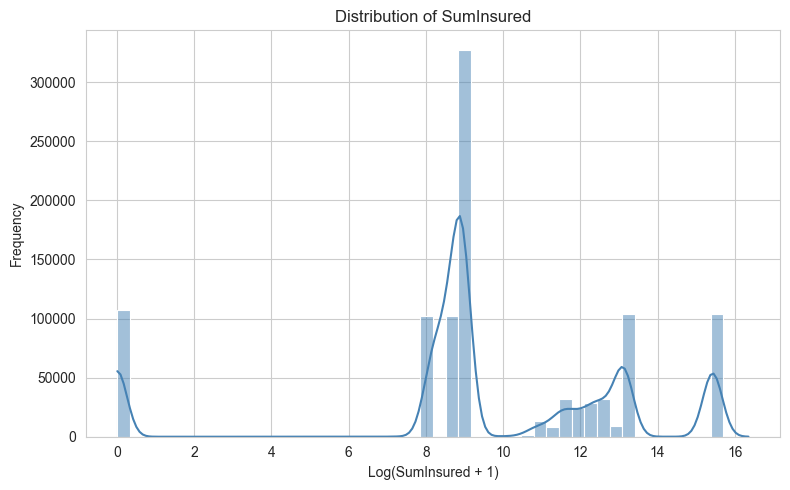

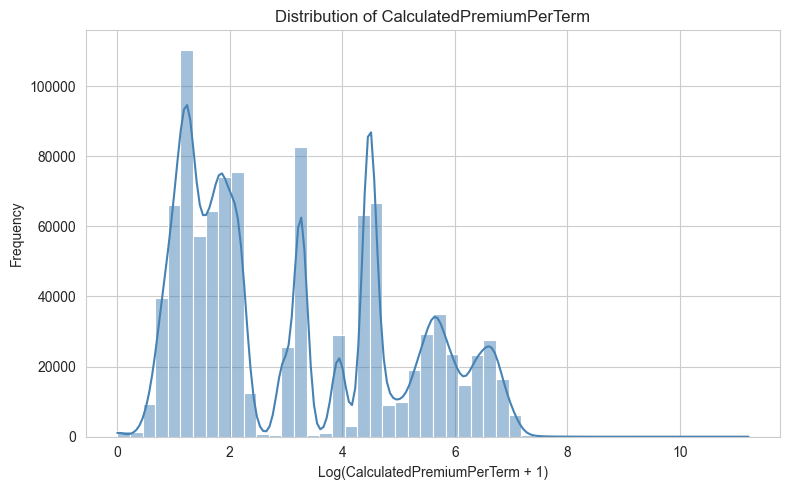

In [87]:
numerical_cols = [
    'TotalPremium',
    'TotalClaims',
    'SumInsured',
    'CalculatedPremiumPerTerm'
]

# Use log transformation for skewed insurance data
for col in numerical_cols:

    plt.figure(figsize=(8,5))

    transformed = np.log1p(
        df[col].clip(lower=0)
    )

    sns.histplot(
        transformed,
        bins=50,
        kde=True,
        color='steelblue'
    )

    plt.title(f'Distribution of {col}')

    plt.xlabel(f'Log({col} + 1)')

    plt.ylabel('Frequency')

    plt.tight_layout()

    plt.show()

In [88]:
numerical_cols

['TotalPremium', 'TotalClaims', 'SumInsured', 'CalculatedPremiumPerTerm']

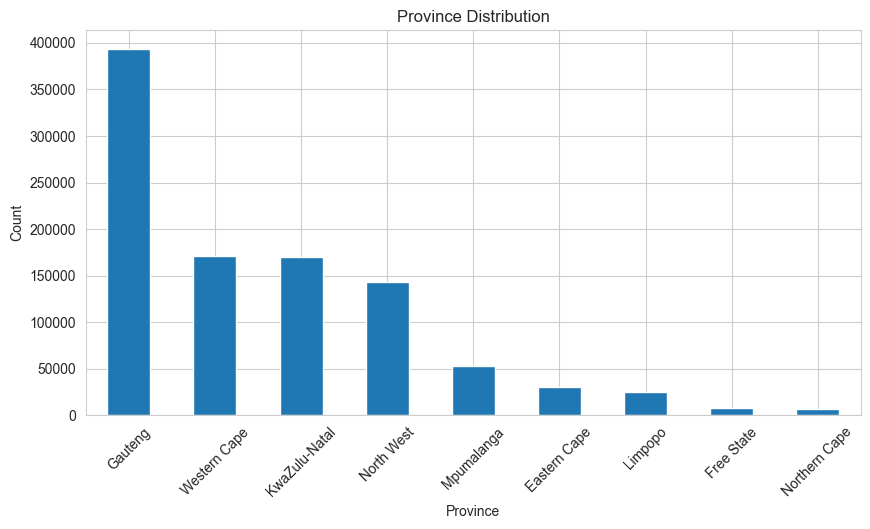

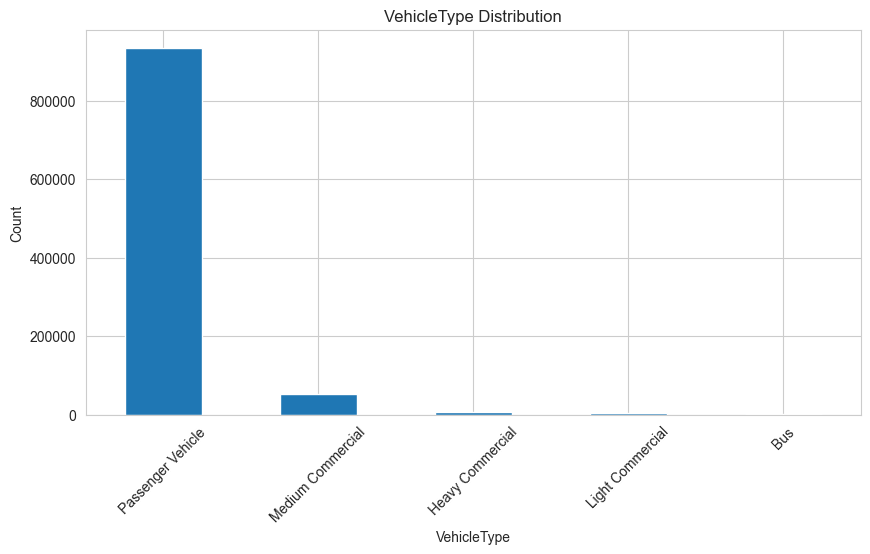

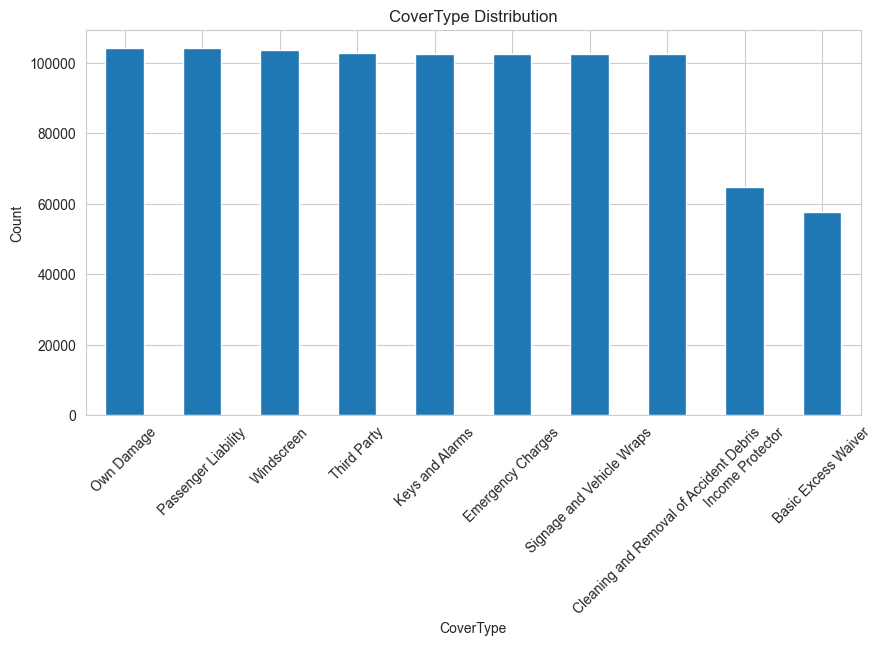

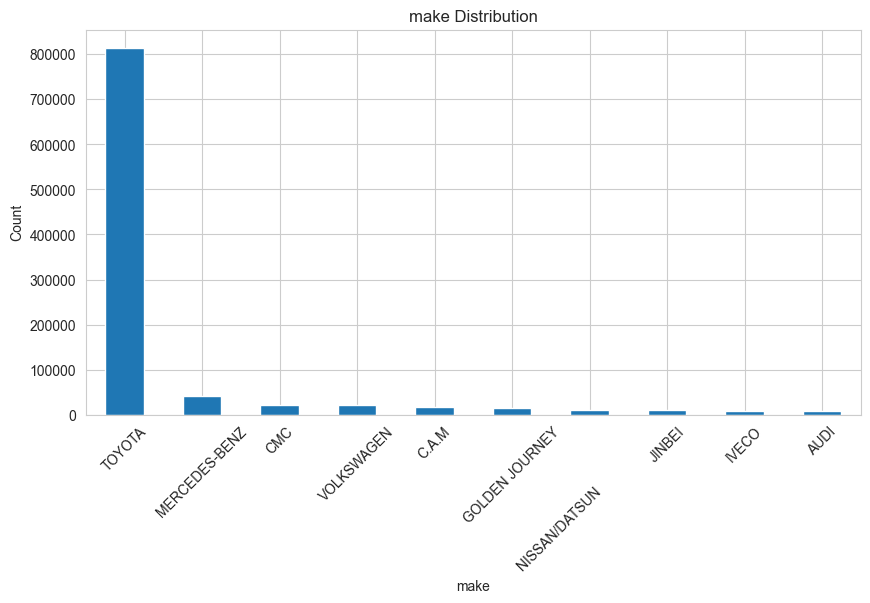

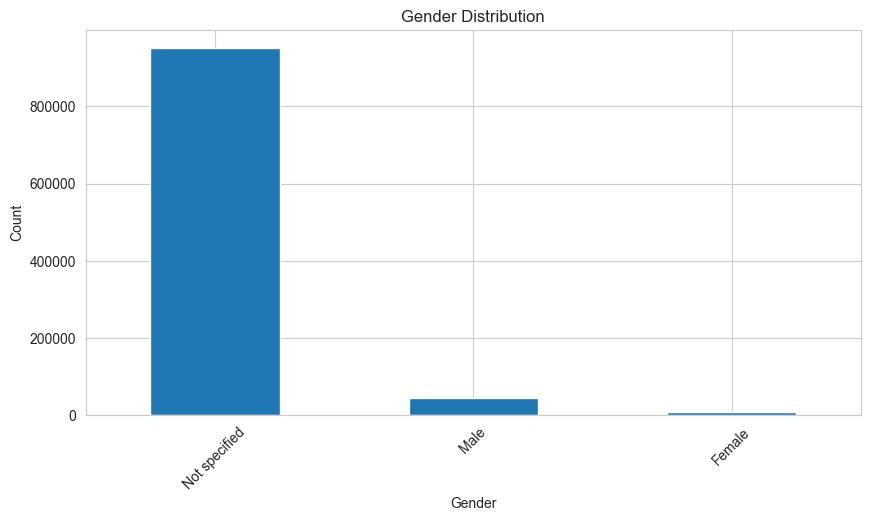

In [89]:
categorical_cols = [
    'Province',
    'VehicleType',
    'CoverType',
    'make',
    'Gender'
]
for col in categorical_cols:

        plt.figure(figsize=(10, 5))

        df[col].value_counts().head(10).plot(
            kind='bar'
        )

        plt.title(f'{col} Distribution')

        plt.xlabel(col)

        plt.ylabel('Count')

        plt.xticks(rotation=45)

        plt.show()

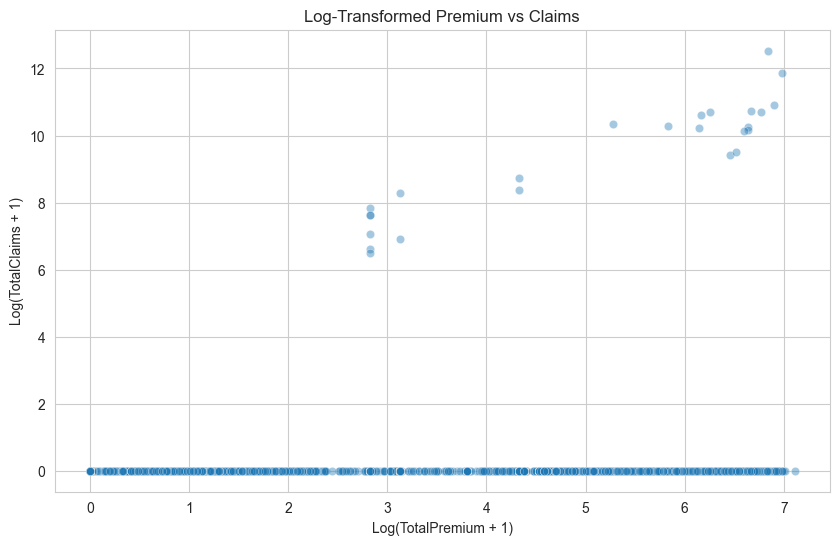

In [31]:
sample_df = df.sample(10000, random_state=42)

sample_df['LogPremium'] = np.log1p(
    sample_df['TotalPremium'].clip(lower=0)
)

sample_df['LogClaims'] = np.log1p(
    sample_df['TotalClaims'].clip(lower=0)
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x='LogPremium',
    y='LogClaims',
    alpha=0.4
)

plt.title('Log-Transformed Premium vs Claims')

plt.xlabel('Log(TotalPremium + 1)')

plt.ylabel('Log(TotalClaims + 1)')

plt.show()

In [32]:
df

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000093,31520,389,2015-04-01,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000094,31520,389,2015-06-01,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000095,31520,389,2015-08-01,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Third Party,Third Party,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,347.235175,0.0
1000096,31519,389,2014-07-01,False,ZW,Individual,Mr,English,ABSA Bank,Savings account,...,No excess,Passenger Liability,Passenger Liability,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,2.315000,0.0


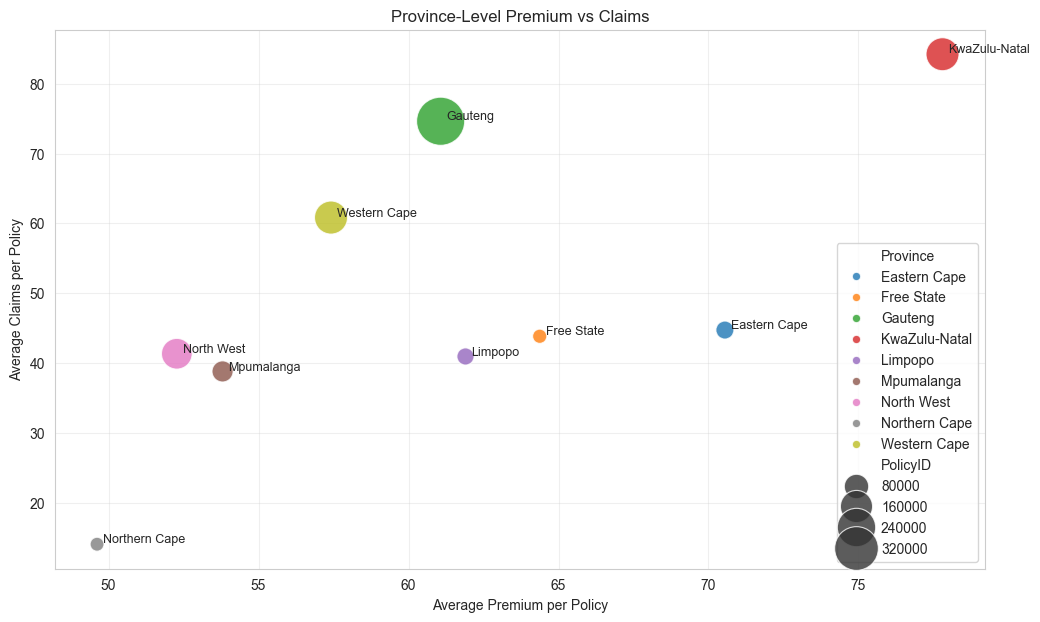

In [33]:
province_summary = df.groupby('Province').agg({
    'TotalPremium': 'mean',
    'TotalClaims': 'mean',
    'PolicyID': 'count'
}).reset_index()
plt.figure(figsize=(12,7))

scatter = sns.scatterplot(
    data=province_summary,
    x='TotalPremium',
    y='TotalClaims',
    size='PolicyID',
    hue='Province',
    sizes=(100, 1200),
    alpha=0.8
)

# Add province labels
for i, row in province_summary.iterrows():

    plt.text(
        row['TotalPremium'] + 0.2,
        row['TotalClaims'] + 0.2,
        row['Province'],
        fontsize=9
    )

plt.title('Province-Level Premium vs Claims')

plt.xlabel('Average Premium per Policy')

plt.ylabel('Average Claims per Policy')
plt.grid(alpha=0.3)

plt.show()

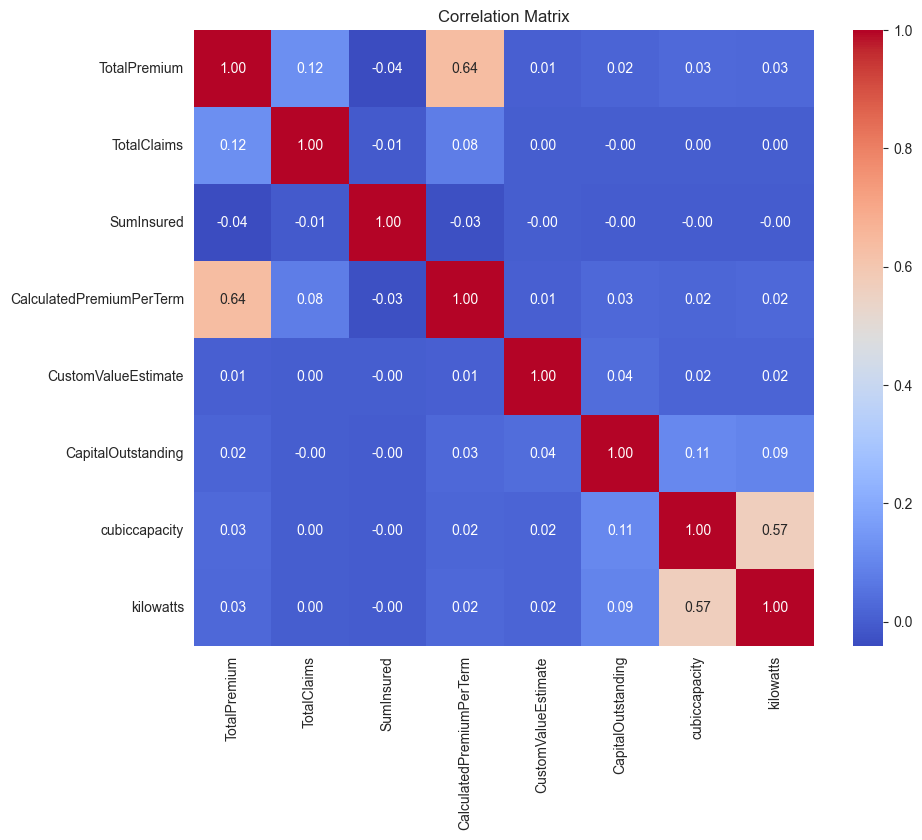

In [34]:
corr_cols = [
    'TotalPremium',
    'TotalClaims',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'CustomValueEstimate',
    'CapitalOutstanding',
    'cubiccapacity',
    'kilowatts'
]

# Compute correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

## Geographic Trends Analysis
### Average Premium Across Provinces

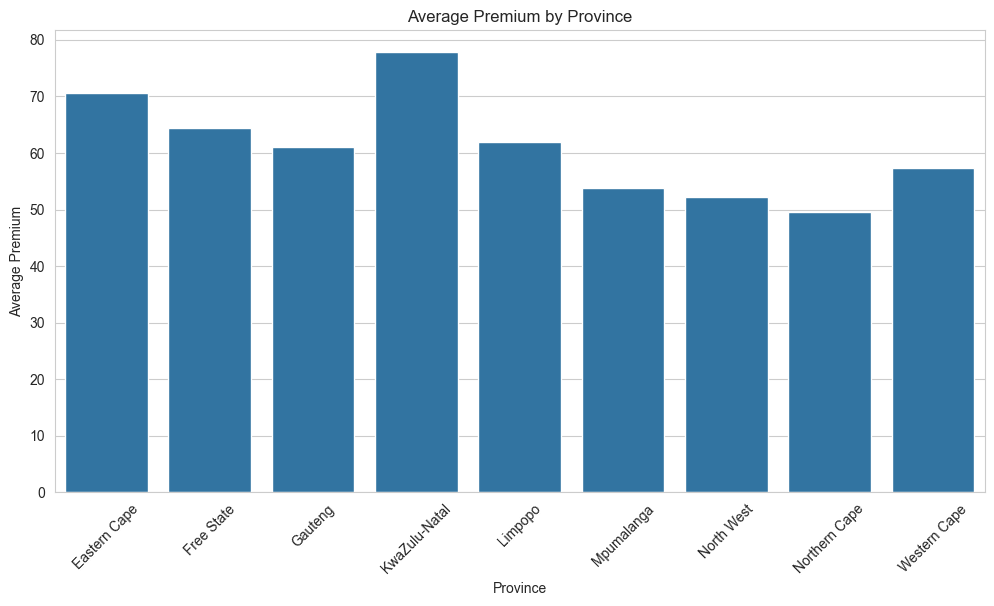

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average premium by province
province_premium = df.groupby('Province')[
    'TotalPremium'
].mean().reset_index()

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=province_premium,
    x='Province',
    y='TotalPremium'
)

plt.title('Average Premium by Province')

plt.xlabel('Province')

plt.ylabel('Average Premium')

plt.xticks(rotation=45)

plt.show()

### Cover Type Distribution Across Provinces

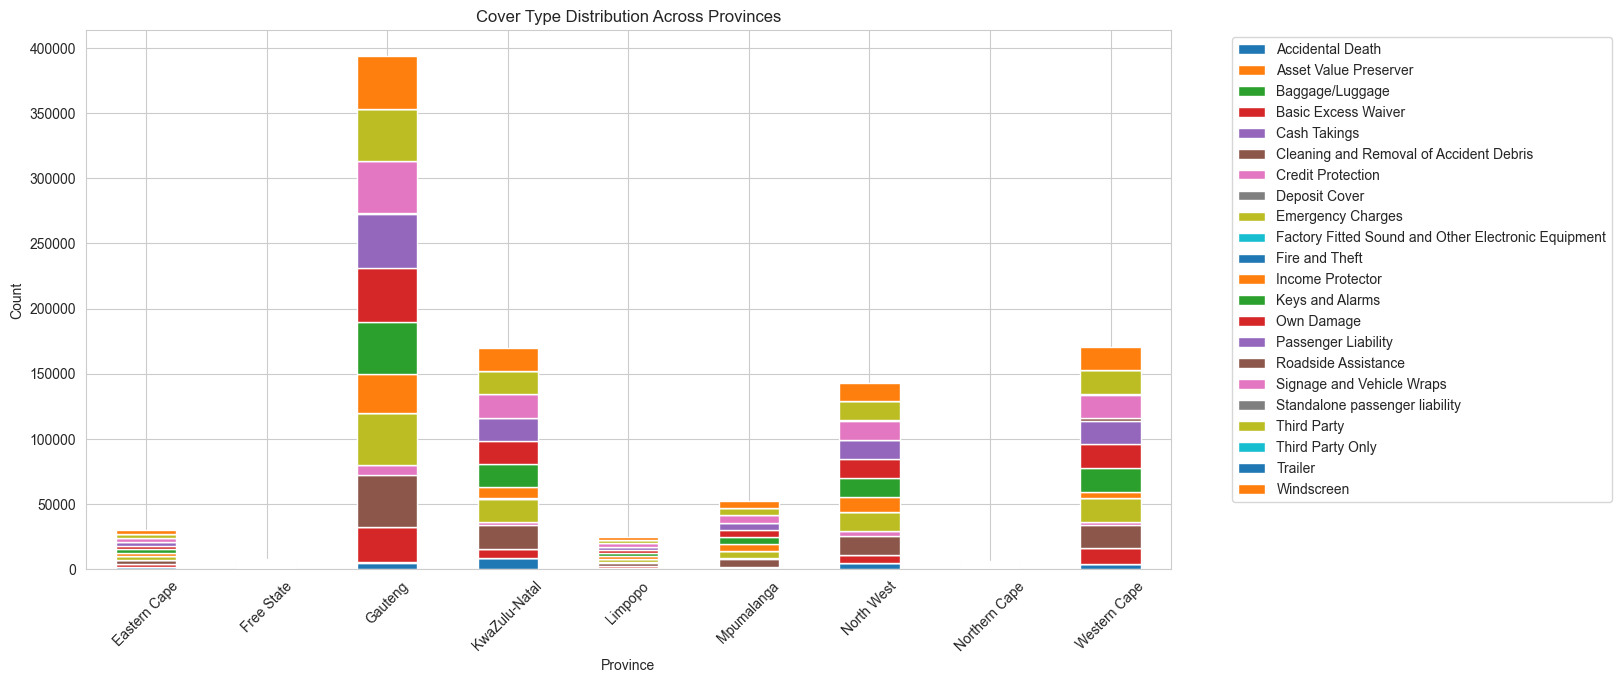

In [29]:
# Cross-tabulation
cover_province = pd.crosstab(
    df['Province'],
    df['CoverType']
)

# Plot
cover_province.plot(
    kind='bar',
    stacked=True,
    figsize=(14,7)
)

plt.title('Cover Type Distribution Across Provinces')

plt.xlabel('Province')

plt.ylabel('Count')

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

### Auto Make Across Provinces

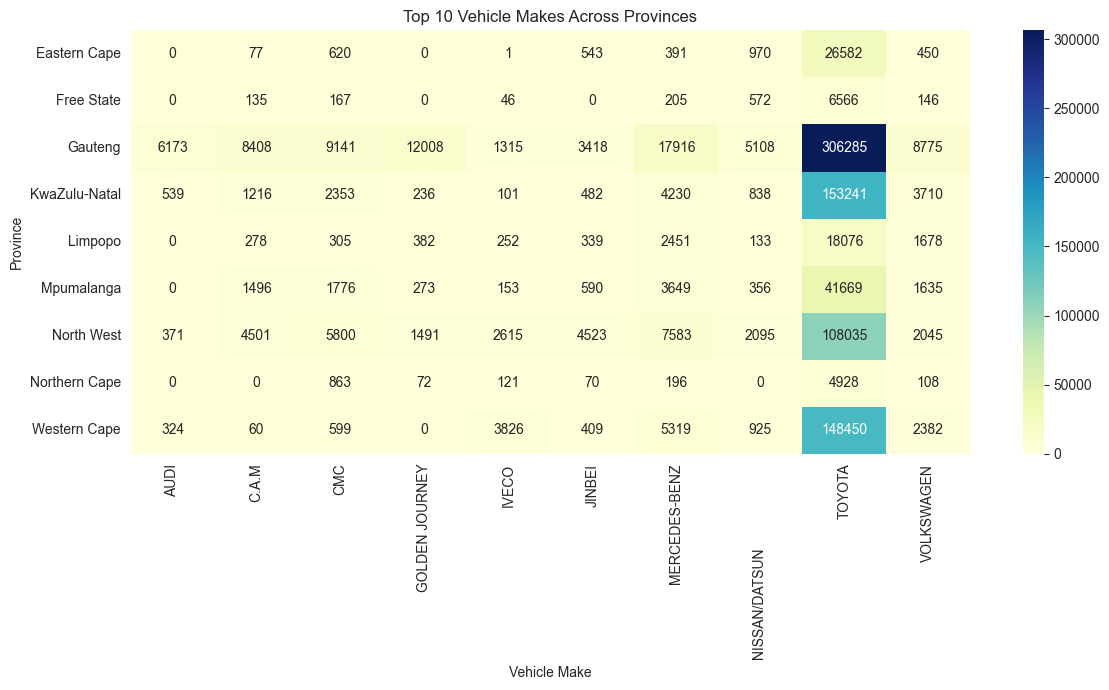

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select top 10 vehicle makes
top_makes = df['make'].value_counts().head(10).index

# Filter dataset
filtered_df = df[df['make'].isin(top_makes)]

# Create pivot table
heatmap_data = pd.crosstab(
    filtered_df['Province'],
    filtered_df['make']
)

# Plot heatmap
plt.figure(figsize=(12,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='g',
    cmap='YlGnBu'
)

plt.title('Top 10 Vehicle Makes Across Provinces')

plt.xlabel('Vehicle Make')

plt.ylabel('Province')

plt.tight_layout()

plt.show()

Toyota was the most dominant vehicle make across all provinces, especially in Gauteng, KwaZulu-Natal, Western Cape, and North West.
Gauteng showed the highest concentration of vehicle policies overall, particularly for Toyota and Mercedes-Benz vehicles.
Western Cape and KwaZulu-Natal also contained substantial numbers of insured Toyota vehicles.
Luxury and commercial vehicle brands such as Mercedes-Benz appeared more concentrated in economically active provinces like Gauteng and North West.

## Outlier Detection

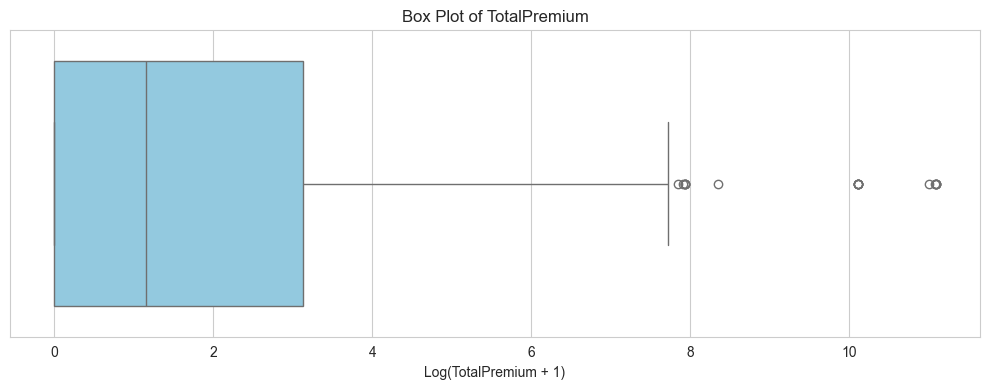

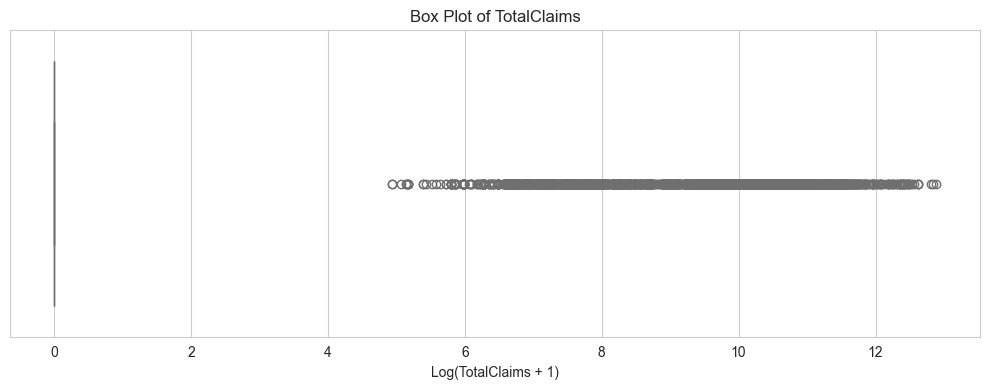

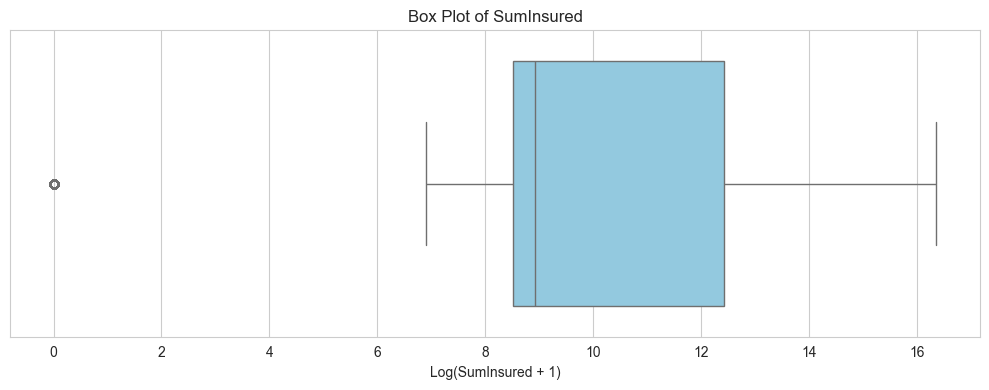

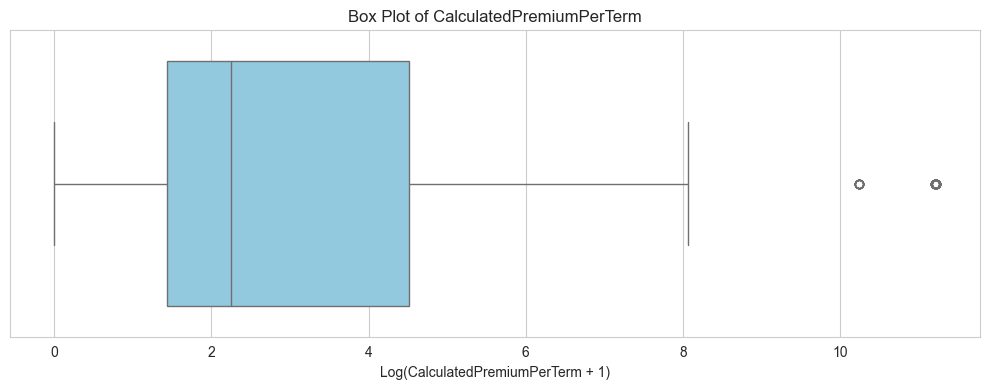

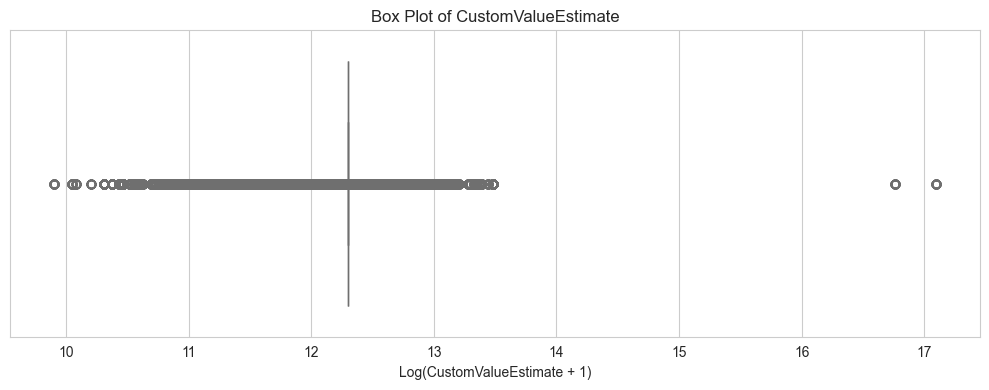

In [62]:
outlier_cols = [
    'TotalPremium',
    'TotalClaims',
    'SumInsured',
    'CalculatedPremiumPerTerm',
    'CustomValueEstimate'
]

# Create box plots
for col in outlier_cols:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        x=np.log1p(df[col].clip(lower=0)),
        color='skyblue'
    )

    plt.title(f'Box Plot of {col}')

    plt.xlabel(f'Log({col} + 1)')

    plt.tight_layout()

    plt.show()

The key financial variables, including TotalPremium, TotalClaims, SumInsured, and CustomValueEstimate, exhibit highly right-skewed distributions. Most observations are concentrated at relatively low values, while a small number of records contain extremely large amounts. 

Significant outliers were identified in both TotalClaims and CustomValueEstimate through box plot analysis. TotalClaims contains a small number of exceptionally high claim amounts, while CustomValueEstimate includes very high-value insured vehicles compared to the majority of the portfolio. 

These extreme values can heavily influence summary statistics, correlations, and predictive models if left untreated. To improve visualization and reduce the effect of skewness, log transformations were applied during exploratory analysis.

## Overall Portfolio Loss Ratio

In [57]:
# Overall portfolio loss ratio
overall_loss_ratio = (
    df['TotalClaims'].sum() /
    df['TotalPremium'].sum()
)

print(f"Overall Loss Ratio: {overall_loss_ratio:.2f}")

Overall Loss Ratio: 1.05


The overall portfolio loss ratio is 1.05, indicating that total claims slightly exceeded total premium income during the analysis period. This suggests that the portfolio operated at a marginal underwriting loss, where claim costs were slightly higher than the premiums collected. A loss ratio above 1.0 may indicate the need for pricing adjustments, improved risk segmentation, or stricter underwriting strategies to improve profitability.

## Loss Ratio by Province

C:\Users\bemnet\AppData\Local\Temp\ipykernel_18800\615771653.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


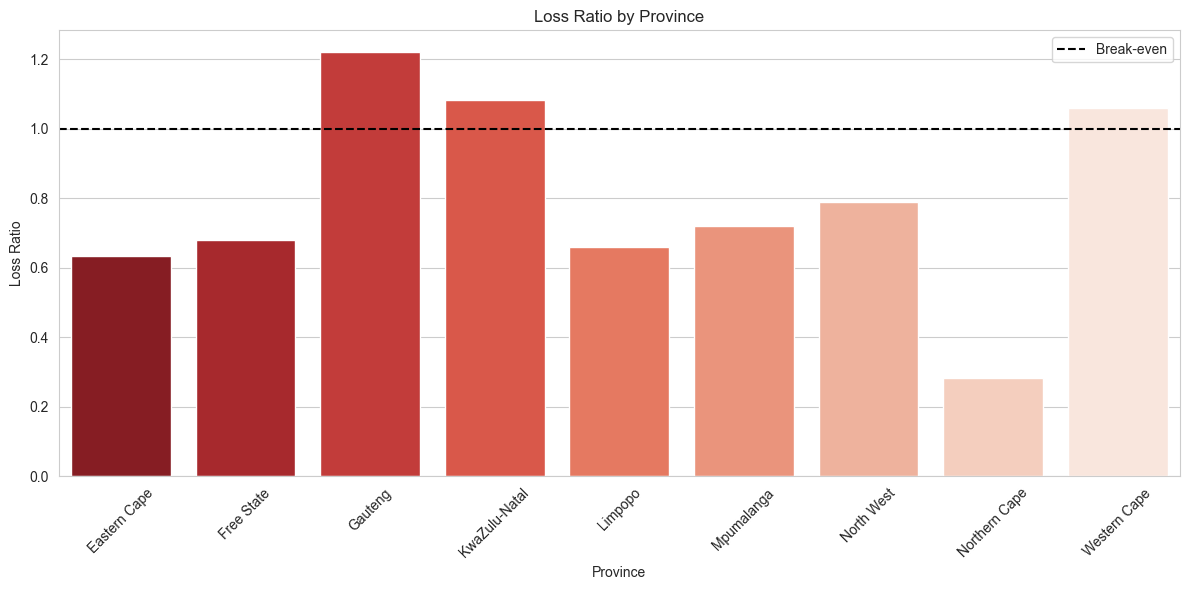

In [28]:
# Province-level loss ratio
province_loss = df.groupby('Province')[[
    'TotalClaims',
    'TotalPremium'
]].sum()

province_loss['LossRatio'] = (
    province_loss['TotalClaims'] /
    province_loss['TotalPremium']
)

province_loss = province_loss.sort_values(
    by='LossRatio',
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=province_loss.index,
    y=province_loss['LossRatio'],
    palette='Reds_r'
)

plt.axhline(
    y=1,
    color='black',
    linestyle='--',
    label='Break-even'
)

plt.title('Loss Ratio by Province')

plt.xlabel('Province')

plt.ylabel('Loss Ratio')

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

The province-level loss ratio analysis shows that Gauteng recorded the highest loss ratio (1.22), indicating claims exceeded premium income and suggesting higher insurance risk and lower profitability in the region. KwaZulu-Natal and Western Cape also showed loss ratios above 1.0, reflecting relatively high claims exposure. 

In contrast, provinces such as Northern Cape, Eastern Cape, and Limpopo recorded lower loss ratios, indicating stronger underwriting profitability and lower relative claims costs. Overall, the results highlight significant geographic differences in portfolio risk across provinces.

## Loss Ratio by Vehicle Type

C:\Users\bemnet\AppData\Local\Temp\ipykernel_18800\1871698500.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


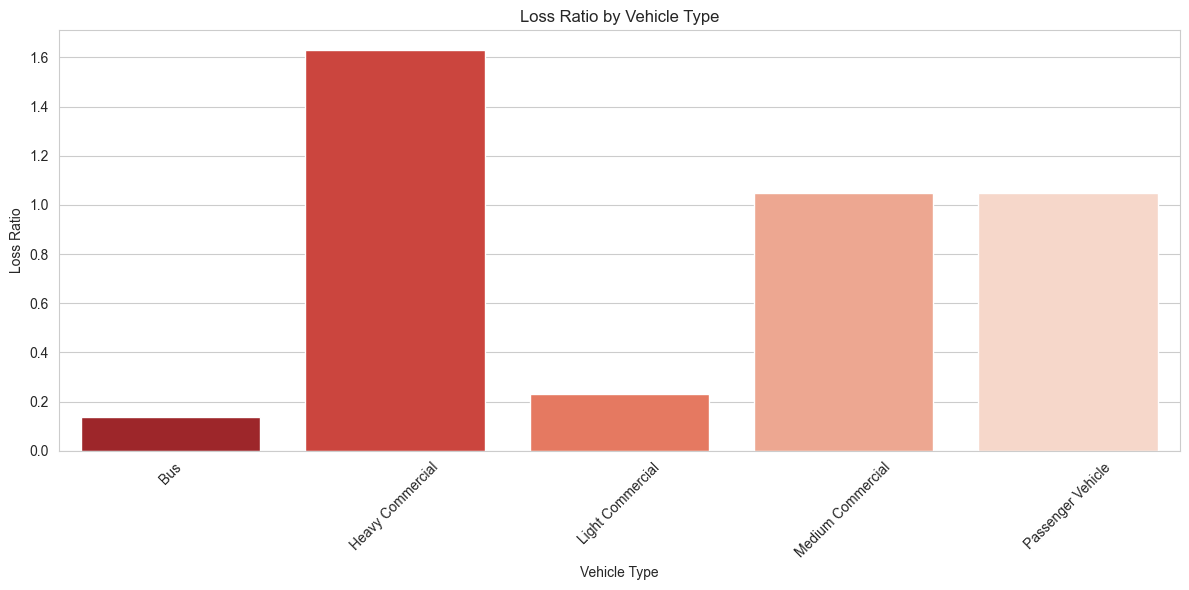

In [27]:
vehicle_loss = df.groupby('VehicleType')[[
    'TotalClaims',
    'TotalPremium'
]].sum()

vehicle_loss['LossRatio'] = (
    vehicle_loss['TotalClaims'] /
    vehicle_loss['TotalPremium']
)

vehicle_loss = vehicle_loss.sort_values(
    by='LossRatio',
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=vehicle_loss.index,
    y=vehicle_loss['LossRatio'],
    palette='Reds_r'
)

plt.title('Loss Ratio by Vehicle Type')

plt.xlabel('Vehicle Type')

plt.ylabel('Loss Ratio')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The loss ratio varies significantly across vehicle types. Heavy Commercial vehicles recorded the highest loss ratio (1.63), indicating claims exceeded premium income and suggesting high insurance risk. Medium Commercial and Passenger Vehicle categories also showed loss ratios slightly above 1.0, reflecting lower profitability. In contrast, Light Commercial and Bus vehicles had much lower loss ratios, indicating stronger portfolio profitability and lower claims exposure.

## Loss Ratio by Gender

In [61]:
gender_loss = df.groupby('Gender')[[
    'TotalClaims',
    'TotalPremium'
]].sum()

gender_loss['LossRatio'] = (
    gender_loss['TotalClaims'] /
    gender_loss['TotalPremium']
)

display(gender_loss[['LossRatio']])

,LossRatio
Gender,
Female,0.821879
Male,0.883910
Not specified,1.053204


Differences in loss ratios between genders may reflect variations in driving behavior, vehicle usage patterns, or exposure levels, although further statistical testing would be required to confirm whether these differences are significant.

## Temporal Trend Analysis
### Monthly Claim Frequency

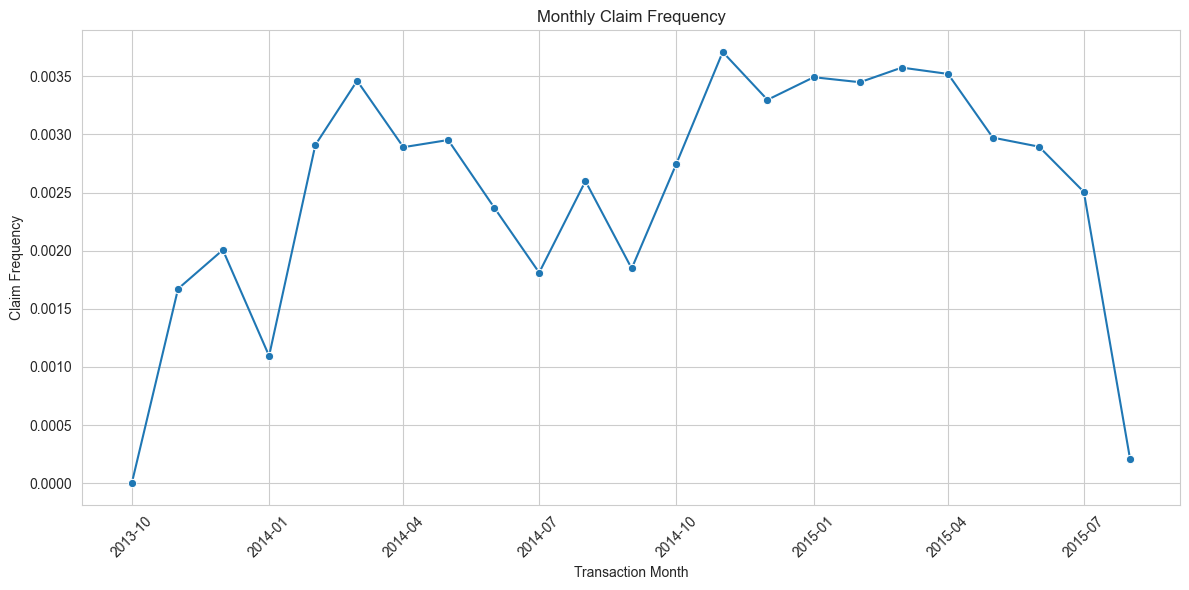

In [63]:
# Create claim indicator
df['HasClaim'] = df['TotalClaims'] > 0

# Monthly claim frequency
claim_frequency = df.groupby(
    'TransactionMonth'
)['HasClaim'].mean().reset_index()

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=claim_frequency,
    x='TransactionMonth',
    y='HasClaim',
    marker='o'
)

plt.title('Monthly Claim Frequency')

plt.xlabel('Transaction Month')

plt.ylabel('Claim Frequency')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The temporal trend analysis shows that claim frequency remained relatively stable throughout most of the 18-month period, with only moderate fluctuations over time.

### Monthly Claim Severity

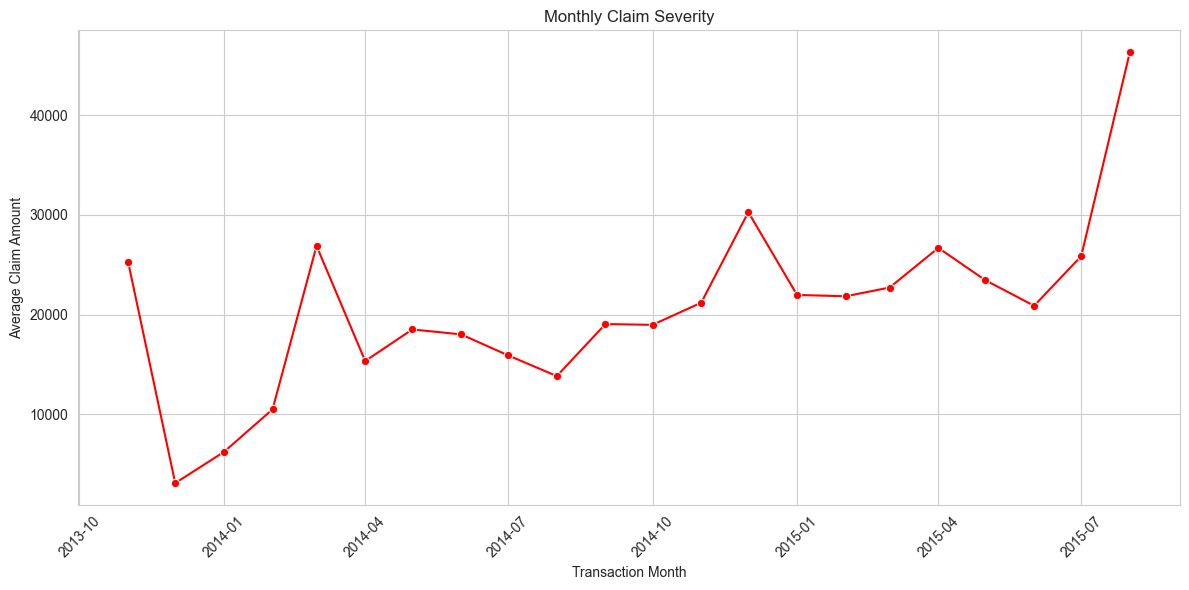

In [64]:
# Filter non-zero claims
claims_only = df[df['TotalClaims'] > 0]

# Monthly claim severity
claim_severity = claims_only.groupby(
    'TransactionMonth'
)['TotalClaims'].mean().reset_index()

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=claim_severity,
    x='TransactionMonth',
    y='TotalClaims',
    marker='o',
    color='red'
)

plt.title('Monthly Claim Severity')

plt.xlabel('Transaction Month')

plt.ylabel('Average Claim Amount')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Claim severity showed greater variability over time. Several months experienced noticeable spikes in average claim amounts, particularly toward mid-2015, indicating the occurrence of a few high-cost claims. The sharp increase in claim severity near the end of the period suggests that while claims were not necessarily more frequent, the financial impact of individual claims became significantly larger during certain months.

## Average Claim Amount by Vehicle Make

In [65]:
# Average claim amount by vehicle make
make_claims = df.groupby('make')[
    'TotalClaims'
].mean().sort_values(ascending=False)

# Highest average claims
highest_make_claims = make_claims.head(10)

# Lowest average claims
lowest_make_claims = make_claims.tail(10)

print("Highest Claim Vehicle Makes")
display(highest_make_claims)

print("\nLowest Claim Vehicle Makes")
display(lowest_make_claims)

Highest Claim Vehicle Makes


make
SUZUKI                                 419.634546
JMC                                    191.684795
HYUNDAI                                174.215195
MARCOPOLO                              156.794806
AUDI                                   137.843083
POLARSUN                               134.044800
B.A.W                                  132.934016
FIAT                                   108.625642
BMW                                     90.558050
IVECO                                   89.667017
Name: TotalClaims, dtype: float64


Lowest Claim Vehicle Makes


make
HINO                                   0.0
JINBEI                                 0.0
LEXUS                                  0.0
PROTON                                 0.0
PEUGEOT                                0.0
OPEL                                   0.0
RENAULT                                0.0
SCANIA                                 0.0
TATA                                   0.0
VOLVO                                  0.0
Name: TotalClaims, dtype: float64

## Average Claim Amount by Vehicle Model

In [66]:
# Average claim amount by vehicle model
model_claims = df.groupby('Model')[
    'TotalClaims'
].mean().sort_values(ascending=False)

# Highest average claims
highest_model_claims = model_claims.head(10)

# Lowest average claims
lowest_model_claims = model_claims.tail(10)

print("Highest Claim Vehicle Models")
display(highest_model_claims)

print("\nLowest Claim Vehicle Models")
display(lowest_model_claims)

Highest Claim Vehicle Models


Model
L/CRUISER FJ 4.0 V6 CRUISER    5340.970273
H-1 2.5 CRDI WAGON A/T         4118.181043
DUCATO 2.3 JTD VETRATO         1014.681021
POLO VIVO 1.6 5Dr               827.558882
C180 BE COUPE                   743.459027
SPRINTER 312D F/C P/V           664.540138
ERTIGA 1.4 GA                   631.774519
YARIS T1 3Dr                    618.719846
A4 1.8T S AVANT MULTITRONIC     480.282859
POLO 1.6 COMFORTLINE            431.842105
Name: TotalClaims, dtype: float64


Lowest Claim Vehicle Models


Model
323 130 STING                        0.000000
YARIS 1.3 5Dr                        0.000000
YARIS T1 5Dr                         0.000000
YARIS T3 A/C                         0.000000
YARIS T3 SPIRIT 5Dr                  0.000000
YARIS T3+                            0.000000
YARIS ZEN3                           0.000000
T5 CARAVELLE 2.0 BiTDi               0.000000
115 VITO 2.2 CDI CREW CAB F/C P/V    0.000000
C200K CLASSIC A/T                   -0.250832
Name: TotalClaims, dtype: float64

The vehicle make and model analysis showed that luxury, commercial, and high-value vehicles generally had the highest average claim amounts. Models such as L/CRUISER FJ 4.0 V6 CRUISER and H-1 2.5 CRDI WAGON A/T recorded the highest claims, while vehicle makes such as SUZUKI, JMC, and HYUNDAI also showed relatively high average claim amounts.

Premium brands including AUDI and BMW exhibited elevated claim severity, suggesting that vehicle value, repair costs, and usage patterns strongly influence insurance claims.

## Province-Level Premium vs Claims Bubble Plot

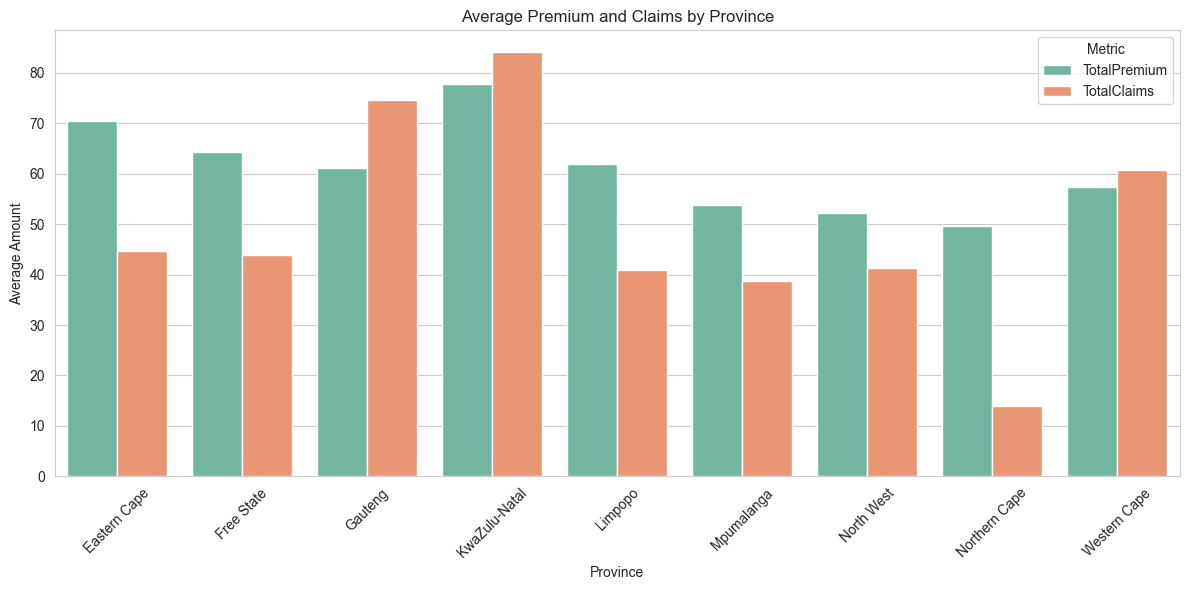

In [69]:
import pandas as pd

# Reshape data
plot_data = province_summary.melt(
    id_vars='Province',
    value_vars=['TotalPremium', 'TotalClaims'],
    var_name='Metric',
    value_name='Value'
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=plot_data,
    x='Province',
    y='Value',
    hue='Metric',
    palette='Set2'
)

plt.title('Average Premium and Claims by Province')

plt.xlabel('Province')

plt.ylabel('Average Amount')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The chart shows that KwaZulu-Natal recorded both the highest average premiums and claims, indicating higher insurance risk and claim exposure. Gauteng and Western Cape also showed relatively high claim amounts compared to other provinces. In contrast, Northern Cape recorded the lowest average claims and premiums, suggesting lower portfolio exposure and stronger profitability.

## Claim Frequency by Province

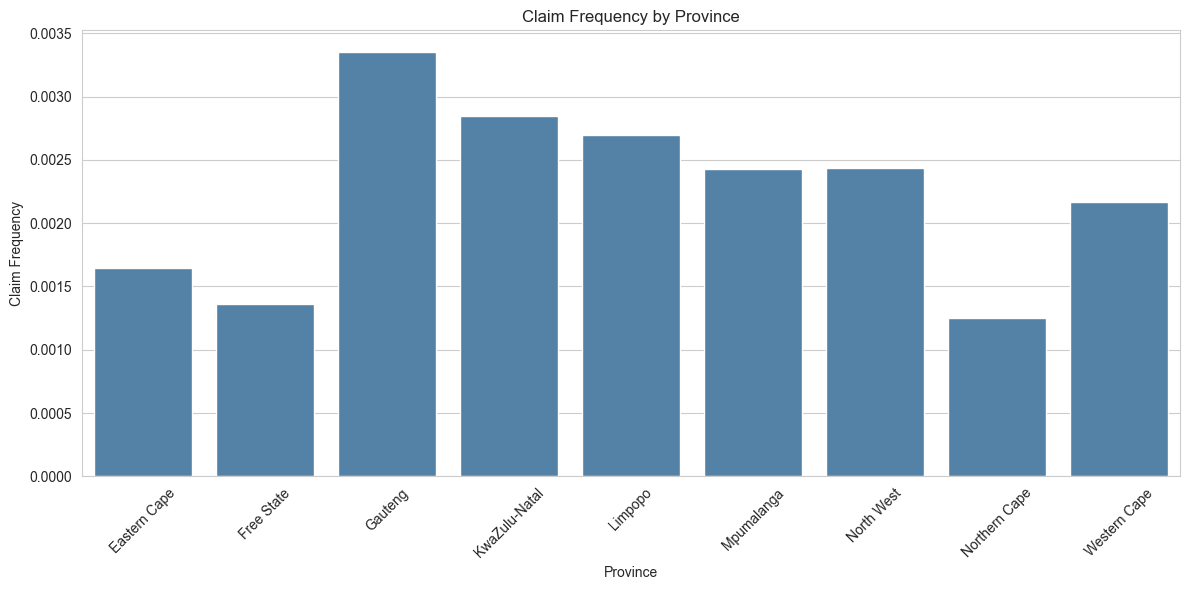

In [23]:
# Create claim indicator
df['HasClaim'] = (
    df['TotalClaims'] > 0
).astype(int)

# Claim frequency
province_frequency = df.groupby('Province')[
    'HasClaim'
].mean().sort_values(
    ascending=False
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=province_frequency.index,
    y=province_frequency.values,
    color='steelblue'
)

plt.title('Claim Frequency by Province')

plt.xlabel('Province')

plt.ylabel('Claim Frequency')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The analysis shows that insurance risk is not evenly distributed across geographic regions.

### Higher-Risk Provinces
- **Gauteng**, **KwaZulu-Natal**, and **Limpopo** recorded higher claim frequencies.
- Policies in these regions are more likely to generate claims, indicating increased insurance risk exposure.

### Business Implications
These provinces may require:
- stricter underwriting policies
- higher premium pricing
- targeted risk management strategies

to maintain portfolio profitability.

### Lower-Risk Provinces
- **Northern Cape** and **Free State** recorded lower claim frequencies.
- These regions represent comparatively lower-risk and potentially more profitable customer segments.

### Strategic Opportunities
Lower-risk provinces may provide opportunities for:
- competitive pricing
- customer acquisition campaigns
- premium reductions for low-risk policyholders

### Overall Business Impact
The findings support the use of **geographic risk segmentation** to improve pricing accuracy, underwriting decisions, and overall portfolio performance.

## Margin Analysis
Margin = TotalPremium − TotalClaims


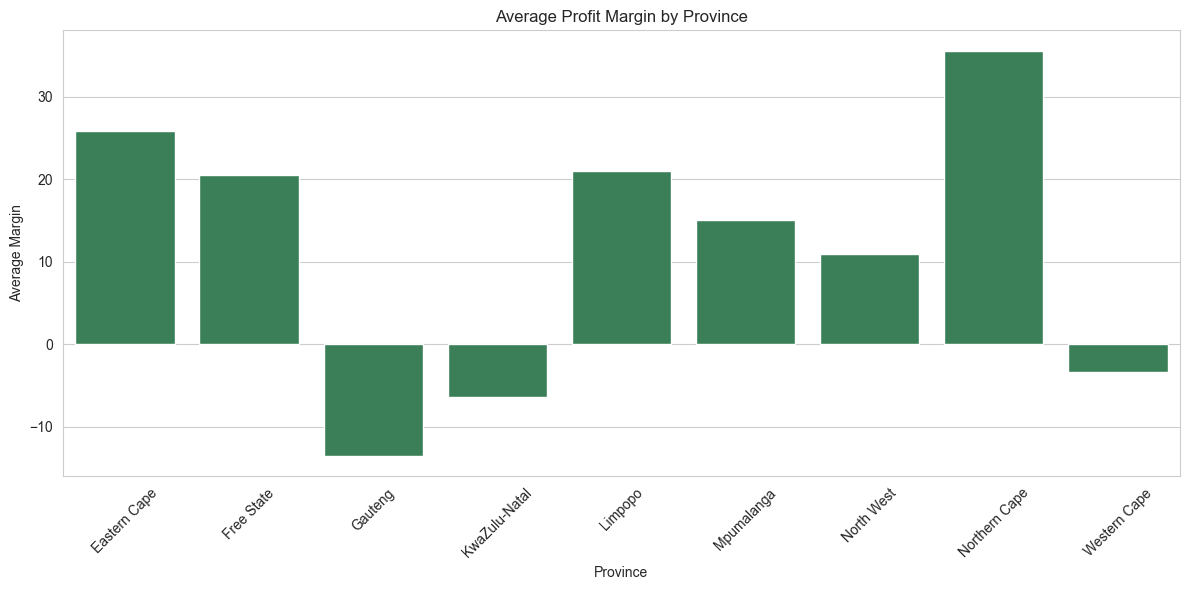

In [26]:
# Calculate margin
df['Margin'] = (
    df['TotalPremium'] -
    df['TotalClaims']
)

# Province margin
province_margin = df.groupby('Province')[
    'Margin'
].mean().sort_values(
    ascending=False
)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=province_margin.index,
    y=province_margin.values,
    color='seagreen'
)

plt.title('Average Profit Margin by Province')

plt.xlabel('Province')

plt.ylabel('Average Margin')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

The profit margin analysis highlights clear differences in underwriting profitability across provinces.

### High-Profit Provinces
- **Northern Cape** recorded the highest average profit margin, indicating strong profitability and lower claims exposure.
- **Eastern Cape**, **Limpopo**, and **Free State** also showed positive margins, suggesting relatively stable and profitable insurance portfolios.

### Low-Profit Provinces
- **Gauteng**, **KwaZulu-Natal**, and **Western Cape** recorded negative average margins, meaning claims exceeded premium income in these regions.
- These provinces may require:
  - premium adjustments
  - stricter underwriting policies
  - enhanced risk management strategies

### Overall Business Impact
The results demonstrate that profitability varies significantly across geographic regions. This supports the use of **province-level risk segmentation** to improve pricing accuracy, underwriting decisions, and overall portfolio performance.

# Test

###  Province Risk Comparison 

#### CLIENT DISTRIBUTION BY PROVINCE

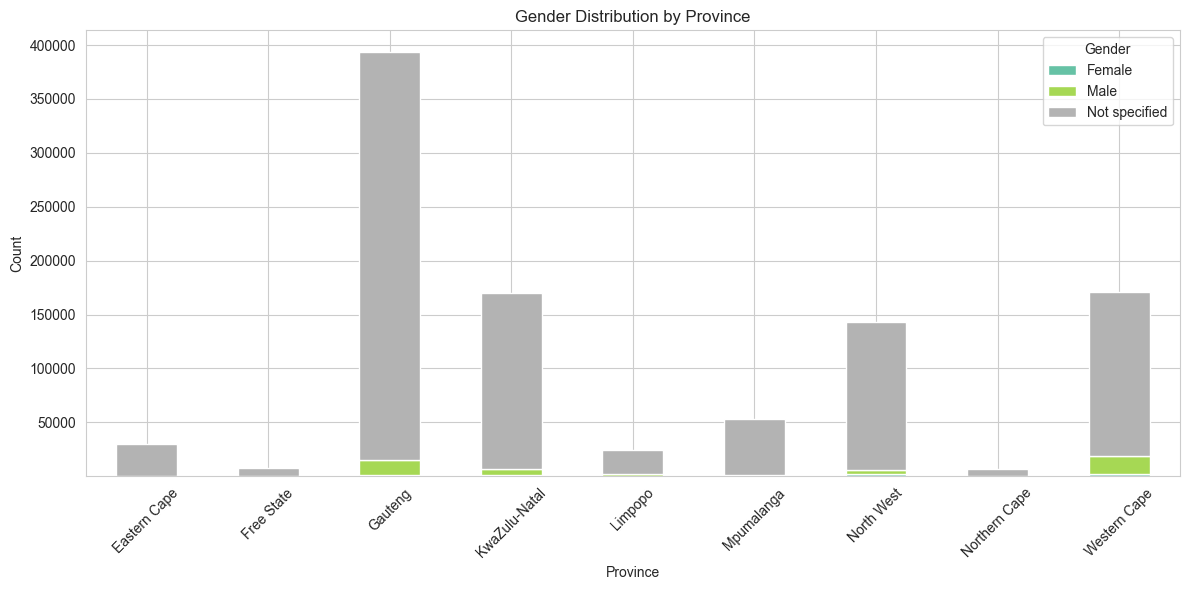

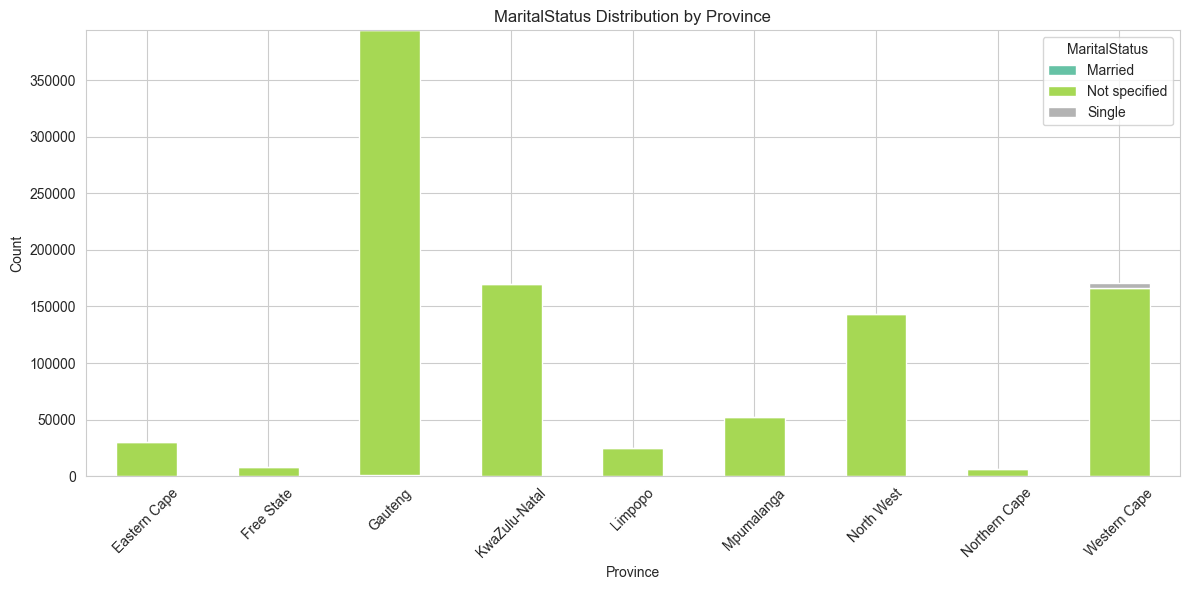

In [43]:
client_cols = [
    'Gender',
    'MaritalStatus'
]

for col in client_cols:

    # Crosstab
    plot_data = pd.crosstab(
        df['Province'],
        df[col]
    )

    # Plot
    plot_data.plot(
        kind='bar',
        stacked=True,
        figsize=(12,6),
        colormap='Set2'
    )

    plt.title(f'{col} Distribution by Province')

    plt.xlabel('Province')

    plt.ylabel('Count')

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

#### VEHICLE DISTRIBUTION BY PROVINCE

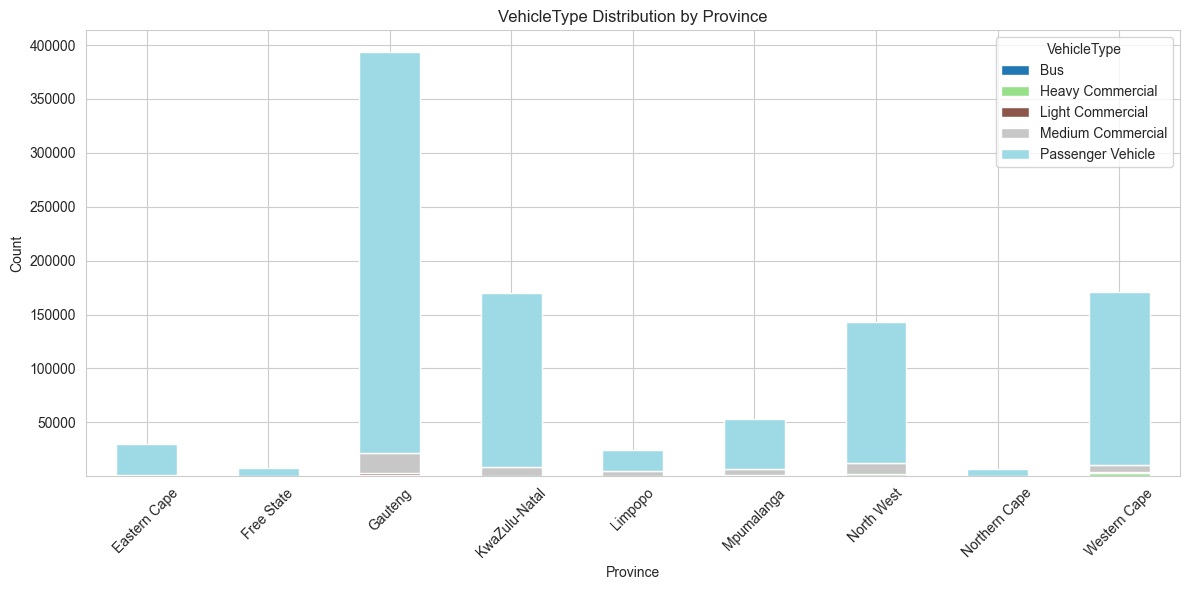

In [47]:
vehicle_cols = [
    'VehicleType'
    # 'make'
]

for col in vehicle_cols:

    # Select top categories
    top_categories = (
        df[col]
        .value_counts()
        .head(5)
        .index
    )

    filtered_df = df[
        df[col].isin(top_categories)
    ]

    # Crosstab
    plot_data = pd.crosstab(
        filtered_df['Province'],
        filtered_df[col]
    )

    # Plot
    plot_data.plot(
        kind='bar',
        stacked=True,
        figsize=(12,6),
        colormap='tab20'
    )

    plt.title(f'{col} Distribution by Province')

    plt.xlabel('Province')

    plt.ylabel('Count')

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

#### PLAN DISTRIBUTION BY PROVINCE

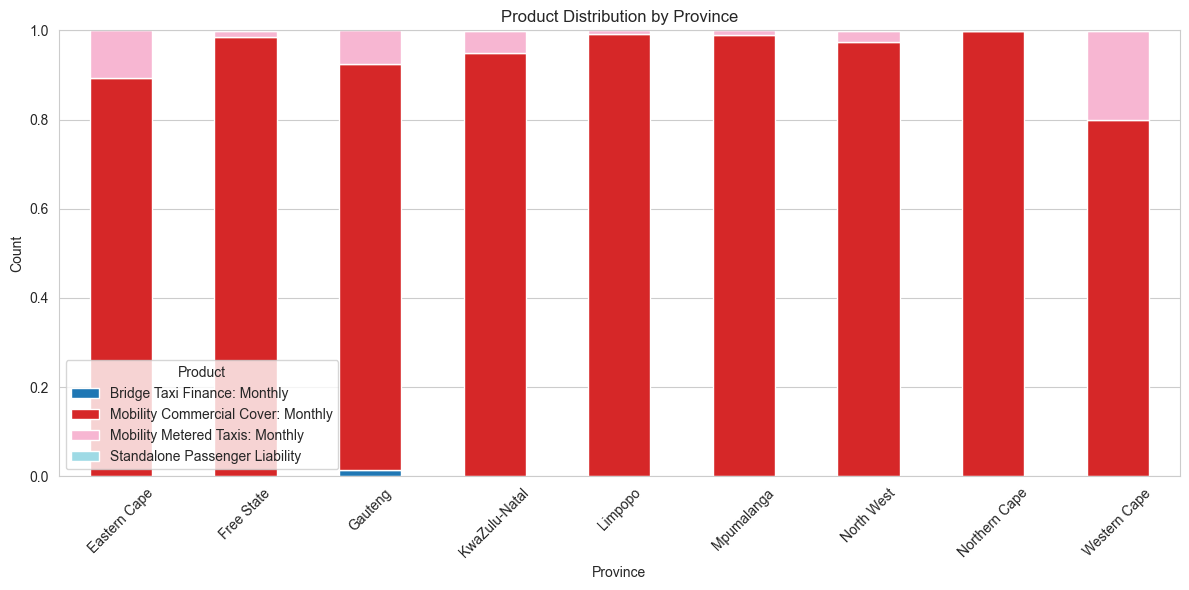

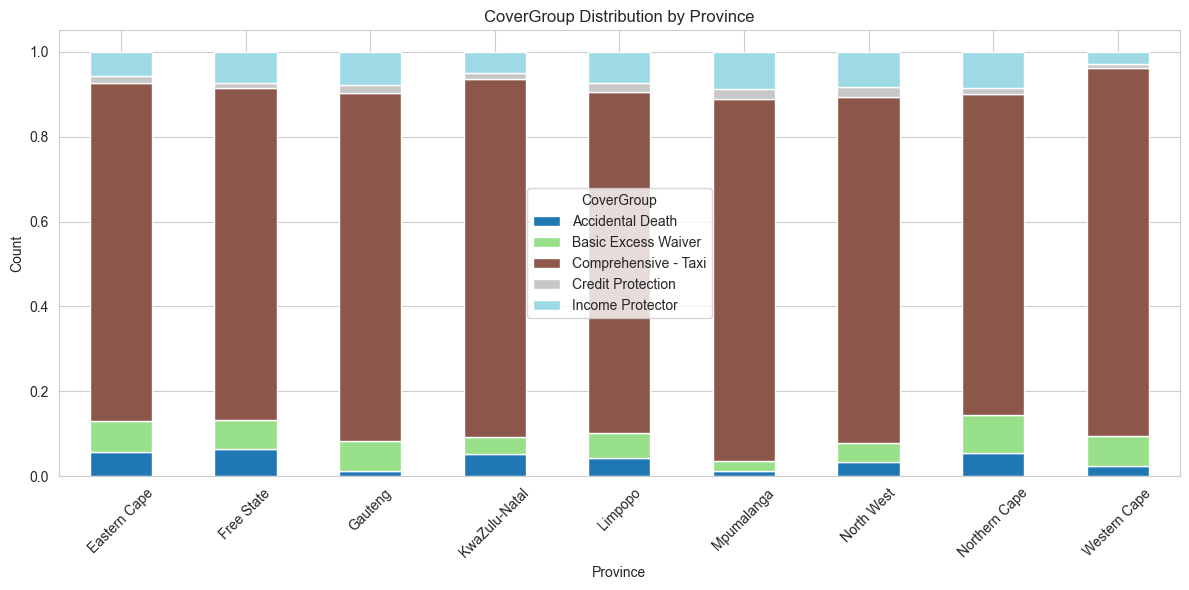

In [46]:
plan_cols = [
    # 'CoverType',
    'Product',
    'CoverGroup'
]

for col in plan_cols:

    # Top categories
    top_categories = (
        df[col]
        .value_counts()
        .head(5)
        .index
    )

    filtered_df = df[
        df[col].isin(top_categories)
    ]

    # Crosstab
    plot_data = pd.crosstab(
    filtered_df['Province'],
    filtered_df[col],
    normalize='index'
)

    # Plot
    plot_data.plot(
        kind='bar',
        stacked=True,
        figsize=(12,6),
        colormap='tab20'
    )

    plt.title(f'{col} Distribution by Province')

    plt.xlabel('Province')

    plt.ylabel('Count')

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

###  Zip Code Risk Comparison

In [64]:
# =========================================
# AUTOMATIC ZIP CODE SELECTION
# =========================================

import pandas as pd
import numpy as np

# -----------------------------------------
# CREATE REQUIRED VARIABLES
# -----------------------------------------

df['HasClaim'] = (
    df['TotalClaims'] > 0
).astype(int)

df['LossRatio'] = (
    df['TotalClaims'] /
    df['TotalPremium']
)

# Remove invalid values
df['LossRatio'] = df['LossRatio'].replace(
    [np.inf, -np.inf],
    np.nan
)

# -----------------------------------------
# ZIP CODE SUMMARY
# -----------------------------------------

zip_summary = df.groupby('PostalCode').agg({

    'PolicyID': 'count',
    'HasClaim': 'mean',
    'TotalClaims': 'mean',
    'TotalPremium': 'mean',
    'LossRatio': 'mean'

}).reset_index()

zip_summary.columns = [
    'PostalCode',
    'PolicyCount',
    'ClaimFrequency',
    'ClaimSeverity',
    'AveragePremium',
    'LossRatio'
]

# -----------------------------------------
# FILTER STABLE ZIP CODES
# -----------------------------------------

filtered_zip = zip_summary[

    # Minimum observations
    (zip_summary['PolicyCount'] >= 100)

    &

    # Must contain claims
    (zip_summary['ClaimFrequency'] > 0)

    &

    # Meaningful claim severity
    (zip_summary['ClaimSeverity'] > 100)

    &

    # Valid loss ratio
    (zip_summary['LossRatio'].notna())

    &

    # Remove extreme outliers
    (zip_summary['LossRatio'] < 15)

    &

     (zip_summary['LossRatio'] > 0.5)

]

# -----------------------------------------
# SORT BY LOSS RATIO
# -----------------------------------------

sorted_zip = filtered_zip.sort_values(
    by='LossRatio'
)

# -----------------------------------------
# SELECT LOWER-RISK ZIP CODE
# -----------------------------------------

low_risk_zip = sorted_zip.iloc[0]

# -----------------------------------------
# FIND COMPARABLE HIGHER-RISK ZIP CODE
# Similar premium level but higher loss ratio
# -----------------------------------------

premium_tolerance = 20

candidate_zip = sorted_zip[

    (
        sorted_zip['AveragePremium']
        >= low_risk_zip['AveragePremium']
        - premium_tolerance
    )

    &

    (
        sorted_zip['AveragePremium']
        <= low_risk_zip['AveragePremium']
        + premium_tolerance
    )

    &

    (
        sorted_zip['LossRatio']
        > low_risk_zip['LossRatio']
    )

]

# Select higher-risk candidate
high_risk_zip = candidate_zip.sort_values(
    by='LossRatio',
    ascending=False
).iloc[0]

# -----------------------------------------
# RESULTS
# -----------------------------------------

print("Selected Lower-Risk Zip Code")
print(low_risk_zip)

print("\nSelected Higher-Risk Zip Code")
print(high_risk_zip)

Selected Lower-Risk Zip Code
PostalCode        4063.000000
PolicyCount       2174.000000
ClaimFrequency       0.007820
ClaimSeverity      153.676613
AveragePremium     101.448477
LossRatio            0.505016
Name: 575, dtype: float64

Selected Higher-Risk Zip Code
PostalCode         81.000000
PolicyCount       669.000000
ClaimFrequency      0.010463
ClaimSeverity     694.309338
AveragePremium     98.461356
LossRatio           3.361927
Name: 20, dtype: float64


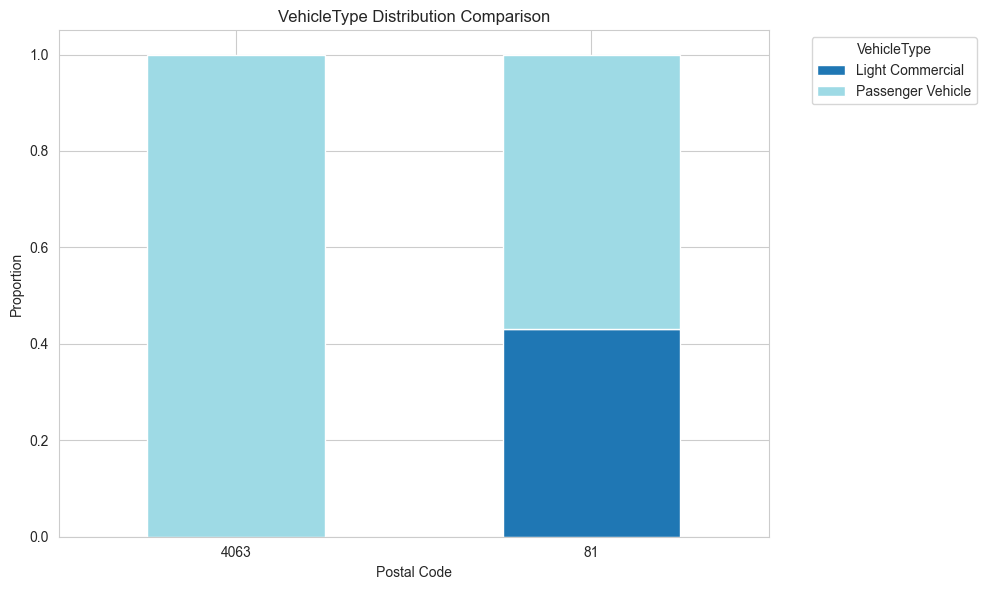

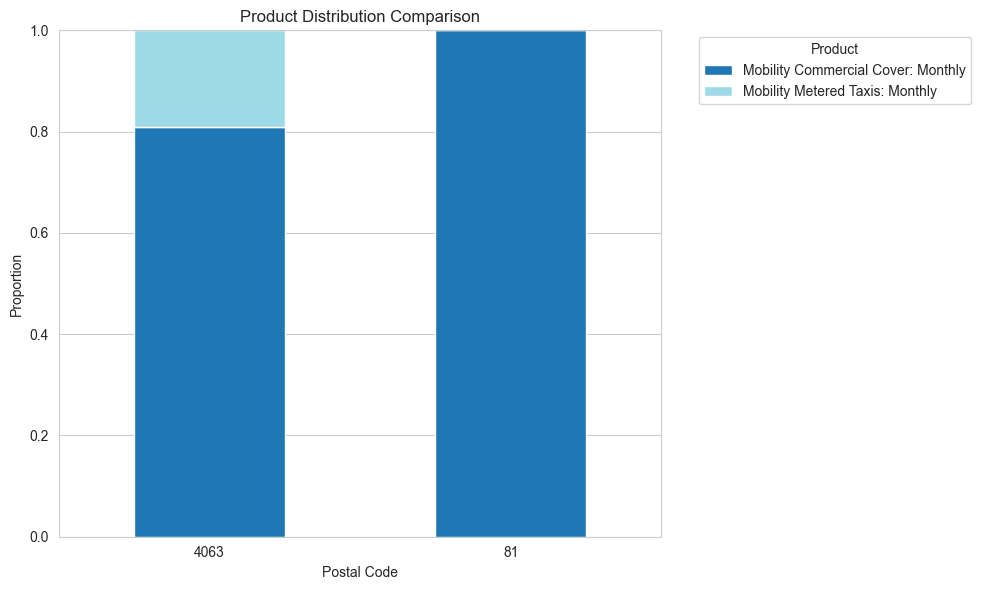

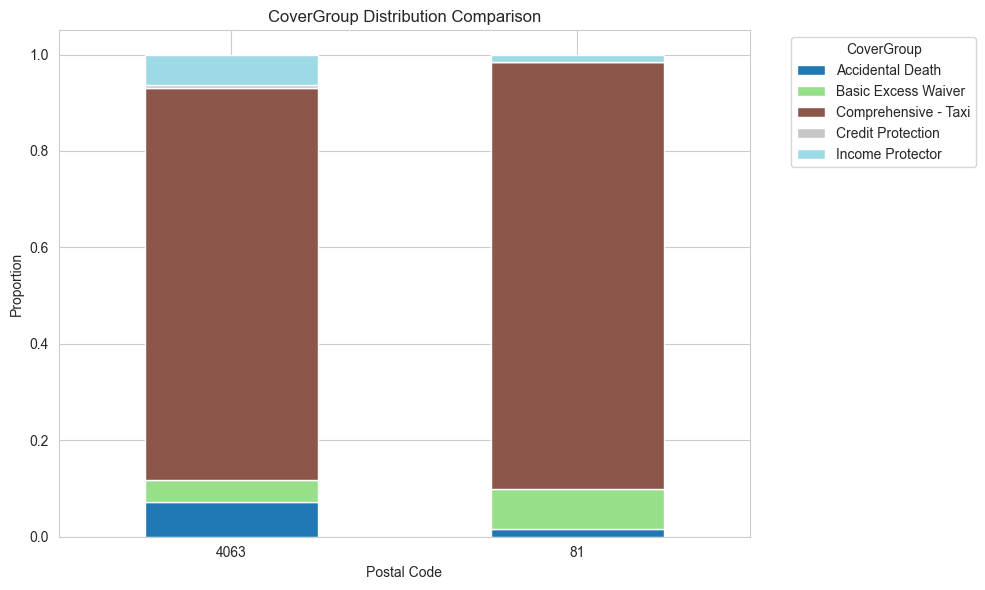

In [69]:
# =========================================
# SELECT ZIP CODES
# =========================================

zip_a = 4063     # Lower-risk zip code
zip_b = 81    # Higher-risk zip code

zip_compare = df[
    df['PostalCode'].isin([zip_a, zip_b])
].copy()

# Convert PostalCode to string
zip_compare['PostalCode'] = zip_compare[
    'PostalCode'
].astype(str)

# =========================================
# FEATURES TO COMPARE
# =========================================

comparison_features = [
    'VehicleType',
    'Product',
    'CoverGroup'
]

# =========================================
# GENERATE COMPARISON PLOTS
# =========================================

for feature in comparison_features:

    # Select top categories
    top_categories = (
        zip_compare[feature]
        .value_counts()
        .head(5)
        .index
    )

    filtered_df = zip_compare[
        zip_compare[feature].isin(top_categories)
    ]

    # Crosstab with proportions
    plot_data = pd.crosstab(
        filtered_df['PostalCode'],
        filtered_df[feature],
        normalize='index'
    )

    # Plot
    plot_data.plot(
        kind='bar',
        stacked=True,
        figsize=(10,6),
        colormap='tab20'
    )

    plt.title(
        f'{feature} Distribution Comparison'
    )

    plt.xlabel('Postal Code')

    plt.ylabel('Proportion')

    plt.xticks(rotation=0)

    plt.legend(
        title=feature,
        bbox_to_anchor=(1.05, 1)
    )

    plt.tight_layout()

    plt.show()
    

### Margin Difference Between Zip Codes 


In [66]:
# =========================================
# ZIP CODE SELECTION FOR MARGIN COMPARISON
# =========================================

import pandas as pd
import numpy as np

# -----------------------------------------
# CREATE MARGIN
# -----------------------------------------

df['Margin'] = (
    df['TotalPremium'] -
    df['TotalClaims']
)

# -----------------------------------------
# ZIP CODE SUMMARY
# -----------------------------------------

zip_margin_summary = df.groupby('PostalCode').agg({

    'PolicyID': 'count',
    'Margin': 'mean',
    'TotalPremium': 'mean',
    'TotalClaims': 'mean'

}).reset_index()

zip_margin_summary.columns = [
    'PostalCode',
    'PolicyCount',
    'AverageMargin',
    'AveragePremium',
    'AverageClaims'
]

# -----------------------------------------
# REMOVE UNSTABLE ZIP CODES
# -----------------------------------------

filtered_margin_zip = zip_margin_summary[

    # Minimum observations
    (zip_margin_summary['PolicyCount'] >= 100)

    &

    # Valid premium values
    (zip_margin_summary['AveragePremium'] > 0)

    &

    # Must contain claims activity
    (zip_margin_summary['AverageClaims'] > 0)

]

# -----------------------------------------
# SORT BY MARGIN
# -----------------------------------------

sorted_margin = filtered_margin_zip.sort_values(
    by='AverageMargin'
)

# -----------------------------------------
# SELECT LOWER-PROFIT ZIP CODE
# -----------------------------------------

low_profit_zip = sorted_margin.iloc[0]

# -----------------------------------------
# FIND COMPARABLE HIGHER-PROFIT ZIP CODE
# Similar premium level but higher margin
# -----------------------------------------

premium_tolerance = 20

candidate_margin_zip = sorted_margin[

    (
        sorted_margin['AveragePremium']
        >= low_profit_zip['AveragePremium']
        - premium_tolerance
    )

    &

    (
        sorted_margin['AveragePremium']
        <= low_profit_zip['AveragePremium']
        + premium_tolerance
    )

    &

    (
        sorted_margin['AverageMargin']
        > low_profit_zip['AverageMargin']
    )

]

# -----------------------------------------
# SELECT HIGHER-PROFIT ZIP CODE
# -----------------------------------------

high_profit_zip = candidate_margin_zip.sort_values(
    by='AverageMargin',
    ascending=False
).iloc[0]

# -----------------------------------------
# RESULTS
# -----------------------------------------

print("Selected Lower-Profit Zip Code")
print(low_profit_zip)

print("\nSelected Higher-Profit Zip Code")
print(high_profit_zip)

Selected Lower-Profit Zip Code
PostalCode        1342.000000
PolicyCount        110.000000
AverageMargin    -1511.886460
AveragePremium      36.525581
AverageClaims     1548.412041
Name: 241, dtype: float64

Selected Higher-Profit Zip Code
PostalCode        1559.000000
PolicyCount       1170.000000
AverageMargin       55.356524
AveragePremium      55.689819
AverageClaims        0.333296
Name: 281, dtype: float64


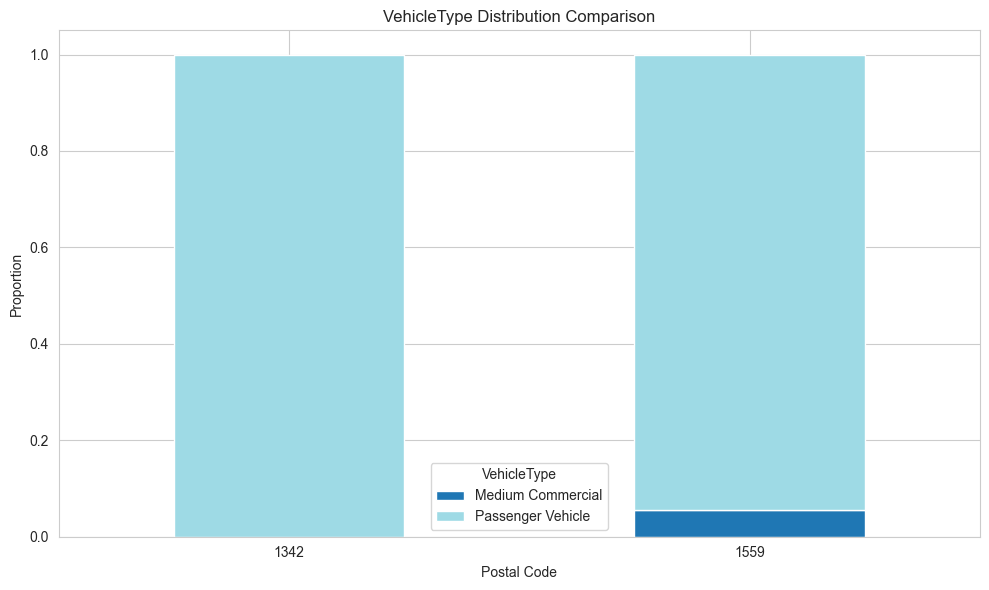

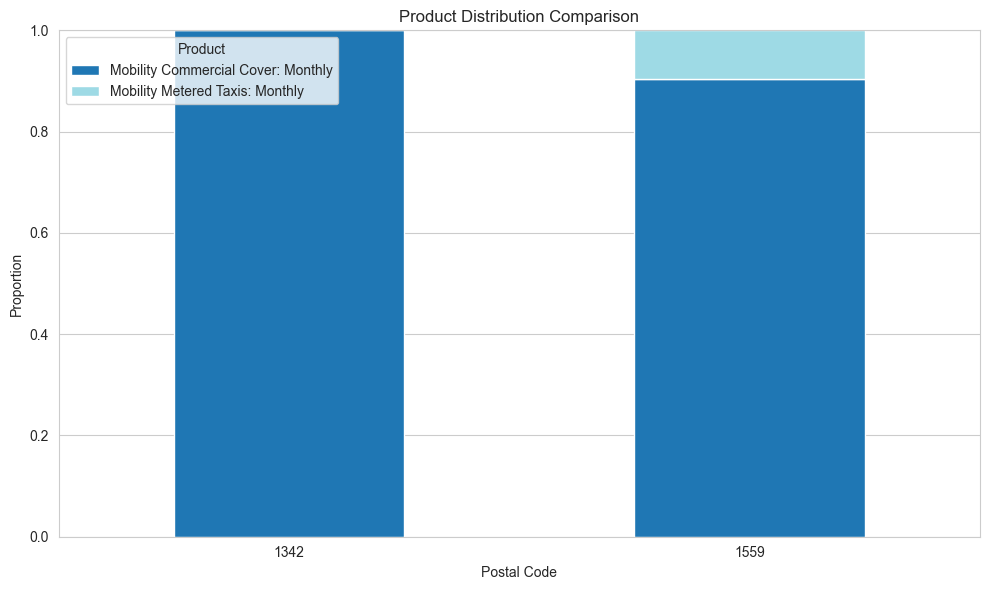

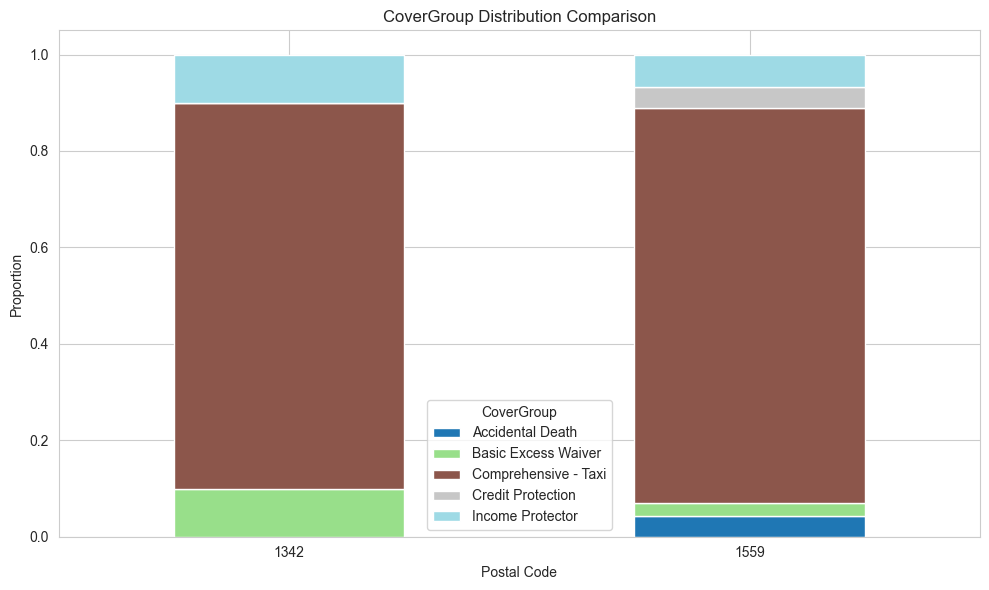

In [68]:
# =========================================
# COMPARE SELECTED ZIP CODES
# =========================================

zip_a = int(low_profit_zip['PostalCode'])
zip_b = int(high_profit_zip['PostalCode'])

zip_compare = df[
    df['PostalCode'].isin([zip_a, zip_b])
].copy()

zip_compare['PostalCode'] = zip_compare[
    'PostalCode'
].astype(str)

comparison_features = [
    'VehicleType',
    'Product',
    'CoverGroup',
]

for feature in comparison_features:

    top_categories = (
        zip_compare[feature]
        .value_counts()
        .head(5)
        .index
    )

    filtered_df = zip_compare[
        zip_compare[feature].isin(top_categories)
    ]

    plot_data = pd.crosstab(
        filtered_df['PostalCode'],
        filtered_df[feature],
        normalize='index'
    )

    plot_data.plot(
        kind='bar',
        stacked=True,
        figsize=(10,6),
        colormap='tab20'
    )

    plt.title(
        f'{feature} Distribution Comparison'
    )

    plt.xlabel('Postal Code')

    plt.ylabel('Proportion')

    plt.xticks(rotation=0)

    plt.tight_layout()

    plt.show()

In [71]:
# =========================================
# IMPORT LIBRARIES
# =========================================

import pandas as pd
import numpy as np

from scipy.stats import (
    chi2_contingency,
    ttest_ind
)

# =========================================
# CREATE REQUIRED VARIABLES
# =========================================

# Claim indicator
df['HasClaim'] = (
    df['TotalClaims'] > 0
).astype(int)

# Margin
df['Margin'] = (
    df['TotalPremium'] -
    df['TotalClaims']
)

# =========================================
# 1. PROVINCE RISK DIFFERENCE
# H0: No risk difference across provinces
# KPI: Claim Frequency
# TEST: Chi-Squared Test
# =========================================

province_df = df[
    df['Province'].isin([
        'Gauteng',
        'Western Cape'
    ])
]

province_table = pd.crosstab(
    province_df['Province'],
    province_df['HasClaim']
)

chi2, province_p, dof, expected = chi2_contingency(
    province_table
)

print("Province Risk Difference Test")
print(f"P-value: {province_p:.5f}")

if province_p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# =========================================
# 2. ZIP CODE RISK DIFFERENCE
# H0: No risk difference between zip codes
# KPI: Claim Frequency
# TEST: Chi-Squared Test
# =========================================

zip_a = 4063
zip_b = 81

zip_df = df[
    df['PostalCode'].isin([
        zip_a,
        zip_b
    ])
]

zip_table = pd.crosstab(
    zip_df['PostalCode'],
    zip_df['HasClaim']
)

chi2, zip_p, dof, expected = chi2_contingency(
    zip_table
)

print("\nZip Code Risk Difference Test")
print(f"P-value: {zip_p:.5f}")

if zip_p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# =========================================
# 3. MARGIN DIFFERENCE BETWEEN ZIP CODES
# H0: No significant margin difference
# KPI: Margin
# TEST: T-Test
# =========================================

margin_zip_a = df[
    df['PostalCode'] == 1342
]['Margin']

margin_zip_b = df[
    df['PostalCode'] == 1559
]['Margin']

t_stat, margin_p = ttest_ind(
    margin_zip_a,
    margin_zip_b,
    equal_var=False,
    nan_policy='omit'
)

print("\nMargin Difference Test")
print(f"P-value: {margin_p:.5f}")

if margin_p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# =========================================
# 4. GENDER RISK DIFFERENCE
# H0: No risk difference between genders
# KPI: Claim Severity
# TEST: T-Test
# =========================================

male_claims = df[
    (df['Gender'] == 'Male') &
    (df['TotalClaims'] > 0)
]['TotalClaims']

female_claims = df[
    (df['Gender'] == 'Female') &
    (df['TotalClaims'] > 0)
]['TotalClaims']

t_stat, gender_p = ttest_ind(
    male_claims,
    female_claims,
    equal_var=False,
    nan_policy='omit'
)

print("\nGender Risk Difference Test")
print(f"P-value: {gender_p:.5f}")

if gender_p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# =========================================
# RESULTS SUMMARY TABLE
# =========================================

results = pd.DataFrame({

    'Hypothesis': [

        'Province Risk Difference',
        'Zip Code Risk Difference',
        'Margin Difference Between Zip Codes',
        'Gender Risk Difference'
    ],

    'KPI': [

        'Claim Frequency',
        'Claim Frequency',
        'Margin',
        'Claim Severity'
    ],

    'Test Used': [

        'Chi-Squared',
        'Chi-Squared',
        'T-Test',
        'T-Test'
    ],

    'P-Value': [

        province_p,
        zip_p,
        margin_p,
        gender_p
    ]

})

results['Decision'] = np.where(

    results['P-Value'] < 0.05,
    'Reject H0',
    'Fail to Reject H0'

)

print("\nHypothesis Testing Results")

display(results)

Province Risk Difference Test
P-value: 0.00000
Reject H0

Zip Code Risk Difference Test
P-value: 0.68038
Fail to Reject H0

Margin Difference Test
P-value: 0.24042
Fail to Reject H0

Gender Risk Difference Test
P-value: 0.56803
Fail to Reject H0

Hypothesis Testing Results


,Hypothesis,KPI,Test Used,P-Value,Decision
0,Province Risk Difference,Claim Frequency,Chi-Squared,6.932050e-14,Reject H0
1,Zip Code Risk Difference,Claim Frequency,Chi-Squared,6.803824e-01,Fail to Reject H0
2,Margin Difference Between Zip Codes,Margin,T-Test,2.404183e-01,Fail to Reject H0
3,Gender Risk Difference,Claim Severity,T-Test,5.680287e-01,Fail to Reject H0


### Gender Risk Comparison
#### Vehicle Type Distribution by Gender

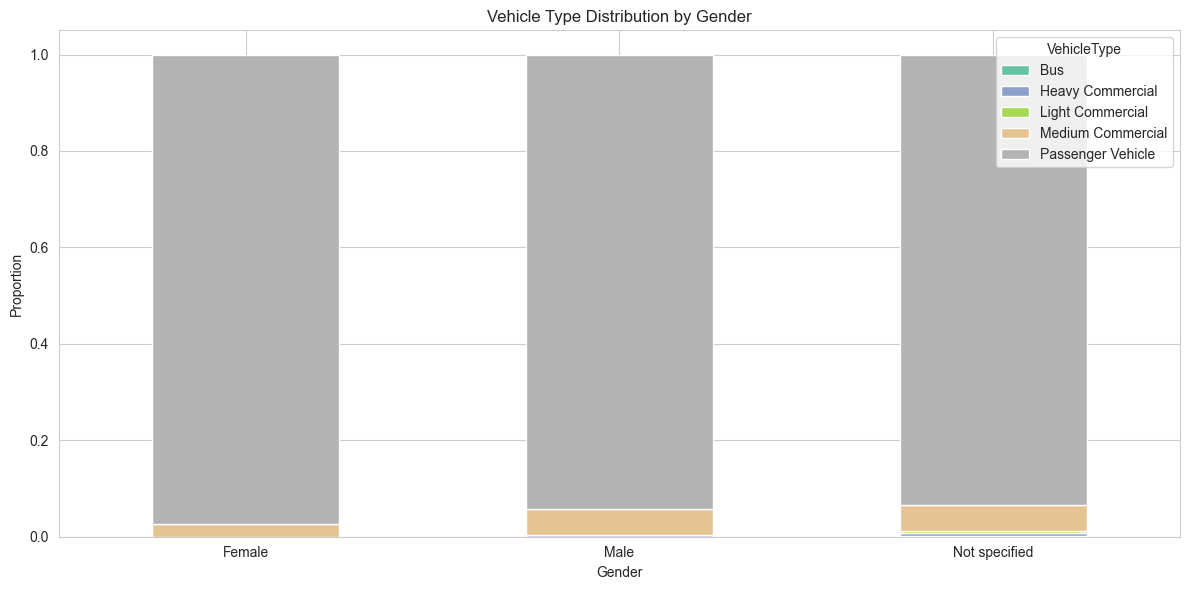

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Crosstab
vehicle_gender = pd.crosstab(
    df['Gender'],
    df['VehicleType'],
    normalize='index'
)

# Plot
vehicle_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='Set2'
)

plt.title('Vehicle Type Distribution by Gender')

plt.xlabel('Gender')

plt.ylabel('Proportion')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

#### Insurance Product Distribution by Gender

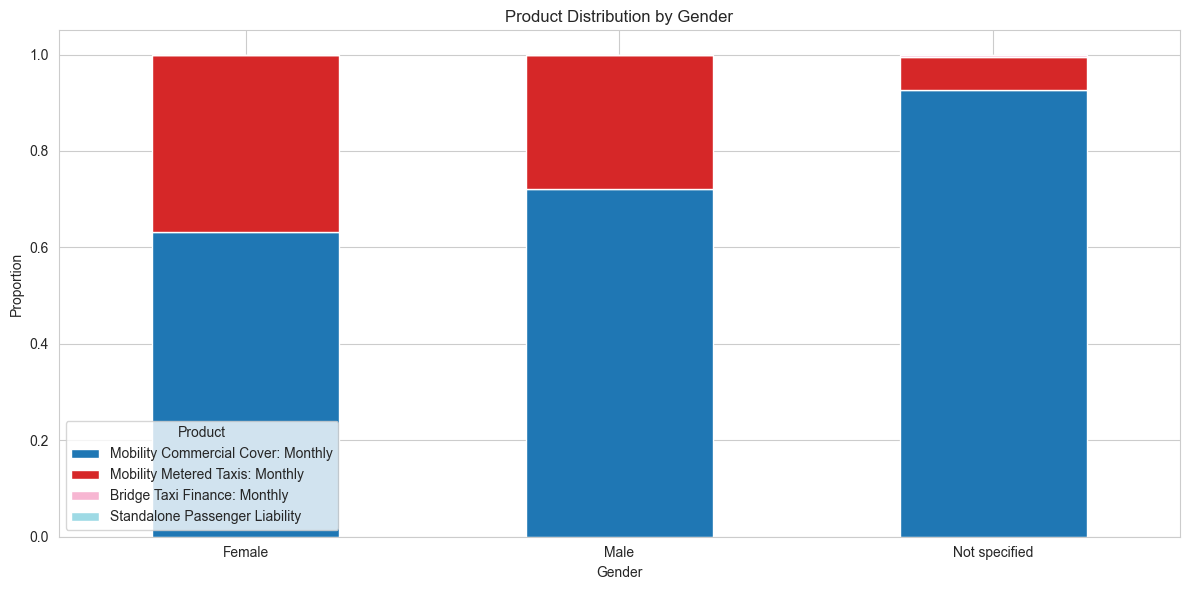

In [73]:
product_gender = pd.crosstab(
    df['Gender'],
    df['Product'],
    normalize='index'
)

# Keep top products only
top_products = (
    df['Product']
    .value_counts()
    .head(5)
    .index
)

product_gender = product_gender[top_products]

# Plot
product_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20'
)

plt.title('Product Distribution by Gender')

plt.xlabel('Gender')

plt.ylabel('Proportion')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

#### Cover Group Distribution by Gender

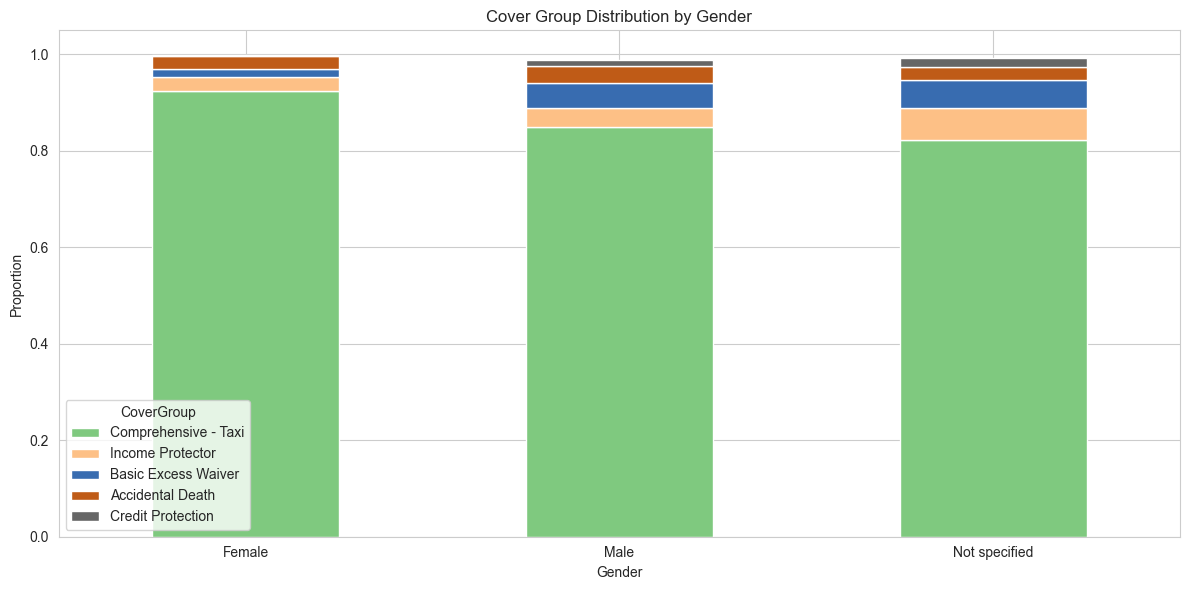

In [74]:
cover_gender = pd.crosstab(
    df['Gender'],
    df['CoverGroup'],
    normalize='index'
)

# Keep top cover groups
top_cover = (
    df['CoverGroup']
    .value_counts()
    .head(5)
    .index
)

cover_gender = cover_gender[top_cover]

# Plot
cover_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='Accent'
)

plt.title('Cover Group Distribution by Gender')

plt.xlabel('Gender')

plt.ylabel('Proportion')

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

#### Claim Severity Comparison by Gender

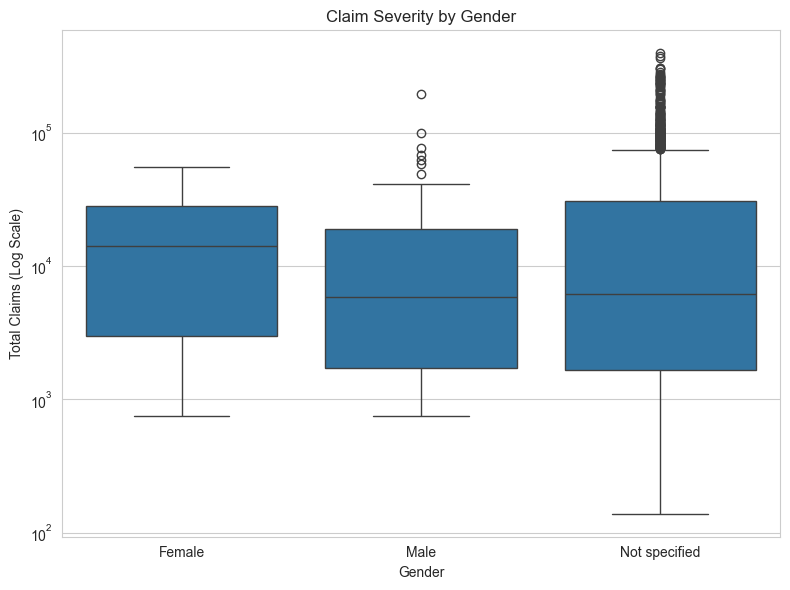

In [75]:
claims_gender = df[
    df['TotalClaims'] > 0
]

plt.figure(figsize=(8,6))

sns.boxplot(
    data=claims_gender,
    x='Gender',
    y='TotalClaims'
)

plt.yscale('log')

plt.title('Claim Severity by Gender')

plt.xlabel('Gender')

plt.ylabel('Total Claims (Log Scale)')

plt.tight_layout()

plt.show()

# Statistical Modeling & Risk-Based Pricing
## Claim Severity Prediction (Risk Model)

In [165]:
claims_df = df[
    df['TotalClaims'] > 0
].copy()
features = [

    'Province',
    'VehicleType',
    'make',
    'CoverType',
    'Gender',
    'TotalPremium',
    'SumInsured',
    'CalculatedPremiumPerTerm'

]
features = [
    col for col in features
    if col in df.columns
]
target = 'TotalClaims'
X = claims_df[features]

y = claims_df[target]


In [166]:
# numerical_cols = X.select_dtypes(
#     exclude=['object']
# ).columns
features

['Province',
 'VehicleType',
 'make',
 'CoverType',
 'Gender',
 'TotalPremium',
 'SumInsured',
 'CalculatedPremiumPerTerm']

In [170]:
categorical_cols = X.select_dtypes(
    include=['category']
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude=['category']
).columns.tolist()

print("Categorical:", categorical_cols)

print("Numerical:", numerical_cols)

Categorical: ['Province', 'VehicleType', 'make', 'CoverType', 'Gender']
Numerical: ['TotalPremium', 'SumInsured', 'CalculatedPremiumPerTerm']


In [171]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
numerical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

In [172]:
from sklearn.preprocessing import OneHotEncoder
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

In [173]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(

    transformers=[

        ('num',
         numerical_transformer,
         numerical_cols),

        ('cat',
         categorical_transformer,
         categorical_cols)

    ]

)

In [174]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

#### Linear Regression

In [175]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# XGBoost
# from xgboost import XGBRegressor

In [176]:
linear_model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', LinearRegression())

])

linear_model.fit(X_train, y_train)

linear_preds = linear_model.predict(X_test)

### Random Forest

In [177]:
rf_model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestRegressor(

        n_estimators=100,

        random_state=42

    ))

])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

### XGBoost

In [178]:
from xgboost import XGBRegressor
xgb_model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', XGBRegressor(

        n_estimators=100,

        learning_rate=0.1,

        max_depth=6,

        random_state=42

    ))

])

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

### Evaluate Models

In [179]:
from src.modeling import evaluate_model

In [180]:
evaluate_model(
    y_test,
    linear_preds,
    'Linear Regression'
)

evaluate_model(
    y_test,
    rf_preds,
    'Random Forest'
)

evaluate_model(
    y_test,
    xgb_preds,
    'XGBoost'
)


Linear Regression
RMSE: 34125.91
R²: 0.2759

Random Forest
RMSE: 36230.78
R²: 0.1838

XGBoost
RMSE: 35790.84
R²: 0.2035


In [181]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)
results = pd.DataFrame({

    'Model': [

        'Linear Regression',
        'Random Forest',
        'XGBoost'

    ],

    'RMSE': [

        np.sqrt(mean_squared_error(
            y_test,
            linear_preds
        )),

        np.sqrt(mean_squared_error(
            y_test,
            rf_preds
        )),

        np.sqrt(mean_squared_error(
            y_test,
            xgb_preds
        ))

    ],

    'R2': [

        r2_score(
            y_test,
            linear_preds
        ),

        r2_score(
            y_test,
            rf_preds
        ),

        r2_score(
            y_test,
            xgb_preds
        )

    ]

})

results

,Model,RMSE,R2
0,Linear Regression,34125.914975,0.275872
1,Random Forest,36230.784361,0.183789
2,XGBoost,35790.842259,0.203491


## SHAP Feature

In [182]:
from xgboost import XGBRegressor

# Preprocess data
X_processed = preprocessor.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(

    X_processed,
    y,

    test_size=0.2,

    random_state=42

)

# Train model
xgb_model = XGBRegressor(

    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42

)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [183]:
encoded_cat_features = preprocessor.named_transformers_[

    'cat'

].named_steps['onehot'].get_feature_names_out(

    categorical_cols

)

feature_names = np.concatenate([

    numerical_cols,
    encoded_cat_features

])

In [184]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

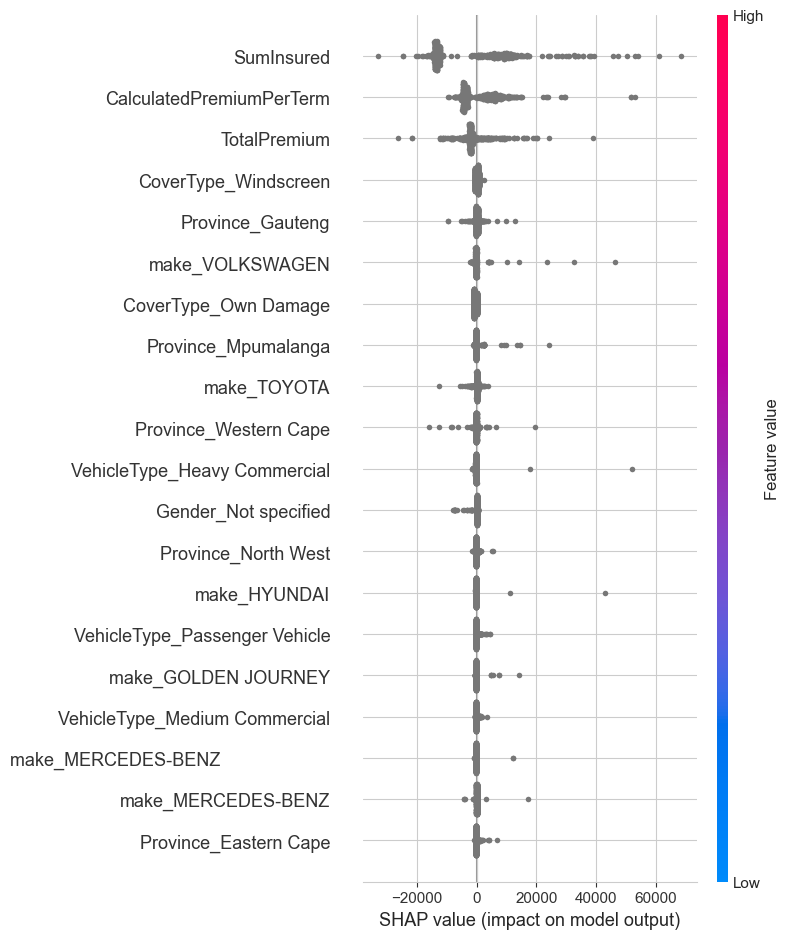

In [185]:
shap.summary_plot(

    shap_values,
    X_test,

    feature_names=feature_names
)

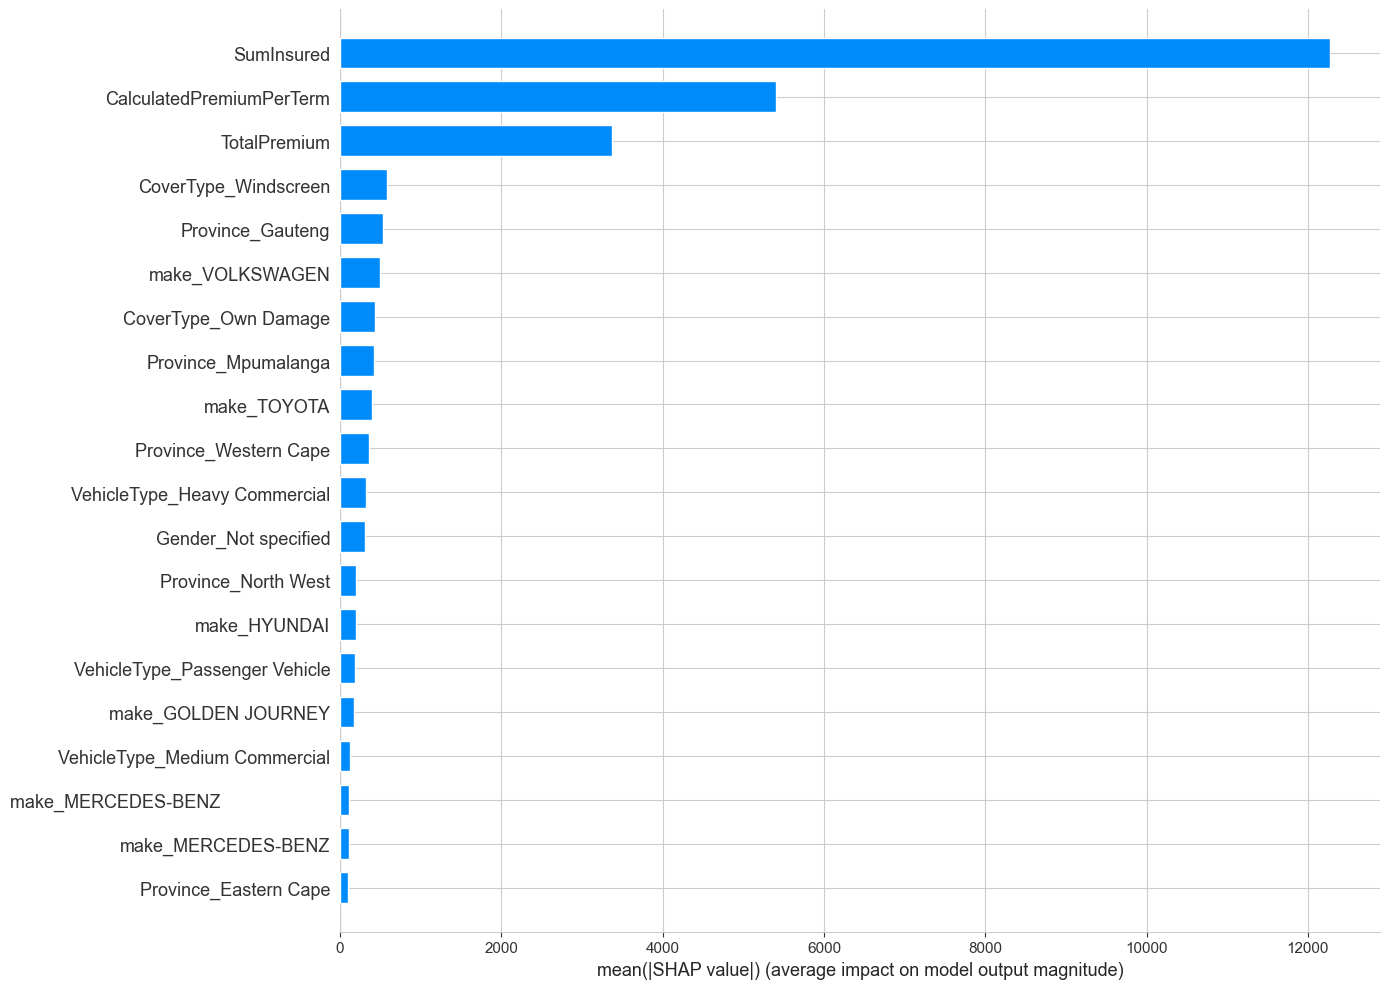

<Figure size 640x480 with 0 Axes>

In [189]:
shap.summary_plot(

    shap_values,
    X_test,

    feature_names=feature_names,

    plot_type='bar',

    max_display=20,

    plot_size=(14,10)

)

plt.gcf().subplots_adjust(
    left=0.35,
    bottom=0.2
)

plt.show()

In [187]:
importance_df = pd.DataFrame({

    'Feature': feature_names,

    'Importance': np.abs(
        shap_values
    ).mean(axis=0)

})

importance_df = importance_df.sort_values(

    by='Importance',
    ascending=False

)

importance_df.head(10)

,Feature,Importance
1,SumInsured,12279.093750
2,CalculatedPremiumPerTerm,5404.796387
0,TotalPremium,3366.511719
53,CoverType_Windscreen,583.275452
5,Province_Gauteng,534.907654
43,make_VOLKSWAGEN,495.395996
50,CoverType_Own Damage,431.834625
8,Province_Mpumalanga,421.295929
41,make_TOYOTA,395.946808
11,Province_Western Cape,360.428833
